# Trend Analysis (SMK) and Seasonality (GLSAR)

In [1]:
colour_1 = "#011428"
colour_2 = "#e8762a"
colour_3 = "#6a86aa"

In [3]:
import math
import pandas as pd
import numpy as np
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates

from shapely.geometry import box
from statsmodels.tsa.seasonal import STL
from matplotlib.ticker import MaxNLocator
from pyproj import Transformer
from pathlib import Path

ROOT = Path("/home/py/groundwater/")
DATA = ROOT / 'data'
GOWN = DATA / 'gown'

In [4]:
df = pd.read_csv(GOWN / 'combined_absval_20052024_filled.csv', parse_dates=[0], index_col=0)
df = df.sort_index(axis=1)
df_m = df.resample("MS").mean()
df_m.index = df_m.index + pd.Timedelta(days=14)

In [5]:
brac = pd.read_csv(DATA / 'bow_valley' / 'stream' / 'cr_flow.csv', index_col=1, parse_dates=[1])
brac = brac.drop(columns=['Unnamed: 0'])
brac = brac.resample("MS").mean()
brac.index = brac.index + pd.Timedelta(days=14)
brac = brac.loc['2005':]
brac

,Flow
Date,
2005-01-15,32.934944
2005-02-15,36.877371
2005-03-15,33.948797
2005-04-15,36.861326
2005-05-15,71.394194
...,...
2023-08-15,55.758224
2023-09-15,39.862387
2023-10-15,27.019511


In [6]:
krns = pd.read_csv(DATA / 'bow_valley' / 'stream' / 'krns.csv', index_col=0, parse_dates=[0])
krns.index = krns.index + pd.Timedelta(days=14)
krns

,Flow
Date,
2005-01-15,4.931935
2005-02-15,4.518214
2005-03-15,5.088387
2005-04-15,5.671333
2005-05-15,17.838710
...,...
2015-08-15,15.670968
2015-09-15,13.613333
2015-10-15,11.508710


In [7]:
order = sorted(df_m.columns)
z = (df_m - df_m.mean()) / df_m.std()

In [8]:
coords = pd.read_csv(GOWN / 'tables' / 'stations.csv', usecols=[3, 5, 6], index_col=0)

In [9]:
def var_fractions(s, period=12):
    r = STL(s, period=period, robust=True).fit()
    v = {"trend": r.trend.var(), "seasonal": r.seasonal.var(), "resid": r.resid.var()}
    tot = sum(v.values())
    return {k: x / tot for k, x in v.items()}

In [10]:
frac = pd.DataFrame({w: var_fractions(df_m[w]) for w in df_m.columns}).T

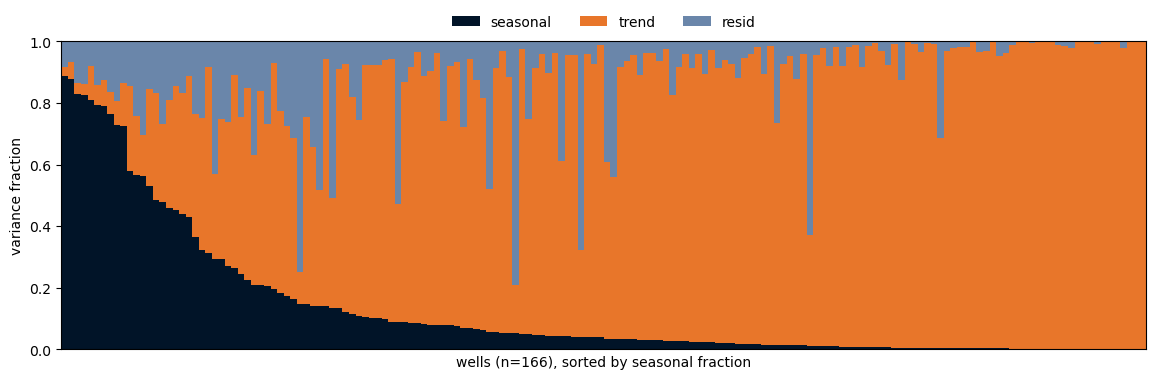

In [11]:
order = frac.sort_values("seasonal", ascending=False).index
fp = frac.loc[order]

fig, ax = plt.subplots(figsize=(14, 4))
bottom = np.zeros(len(fp))
colors = {"trend": colour_2, "seasonal": colour_1, "resid": colour_3}
for comp in ["seasonal", "trend", "resid"]:
    ax.bar(range(len(fp)), fp[comp], bottom=bottom, width=1.0,
           color=colors[comp], label=comp, edgecolor="none")
    bottom += fp[comp].values

ax.set_xlim(-0.5, len(fp)-0.5)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_xlabel(f"wells (n={len(fp)}), sorted by seasonal fraction")
ax.set_ylabel("variance fraction")
ax.legend(ncol=3, frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.0))

(np.float64(-0.05),
 np.float64(1.05),
 np.float64(-0.04330127018922193),
 np.float64(0.9093266739736605))

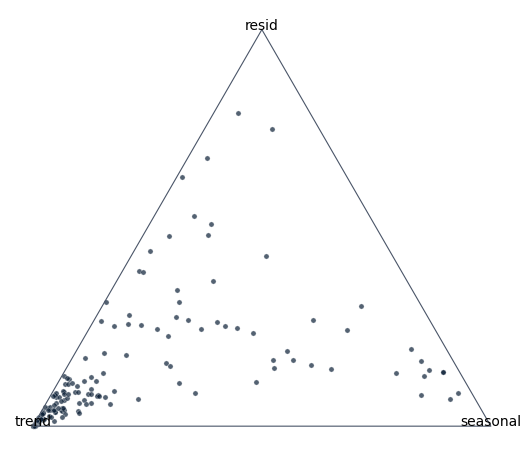

In [12]:
# barycentric -> 2D
t, s, r = frac["trend"], frac["seasonal"], frac["resid"]
x = 0.5 * (2*s + r)          # corners: trend=(0,0), seasonal=(1,0), resid=(0.5,√3/2)
y = (np.sqrt(3)/2) * r

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(x, y, s=14, c="#0b1f36", alpha=0.7, edgecolor="w", lw=0.3)
# triangle frame
tri = np.array([[0,0], [1,0], [0.5, np.sqrt(3)/2], [0,0]])
ax.plot(tri[:,0], tri[:,1], color="#4a5568", lw=0.8)
for (px,py),lab in zip(tri[:3], ["trend","seasonal","resid"]):
    ax.annotate(lab, (px,py), fontsize=10, ha="center")
ax.set_aspect("equal"); ax.axis("off")

In [13]:
comps, fits = {}, {}
for w in df_m.columns:
    r = STL(df_m[w], period=12, robust=True).fit()
    sd = df_m[w].std()
    fits[w] = r
    comps[w] = {"trend": (r.trend - r.trend.mean()) / sd,
                "seasonal": r.seasonal / sd,
                "resid": r.resid / sd}

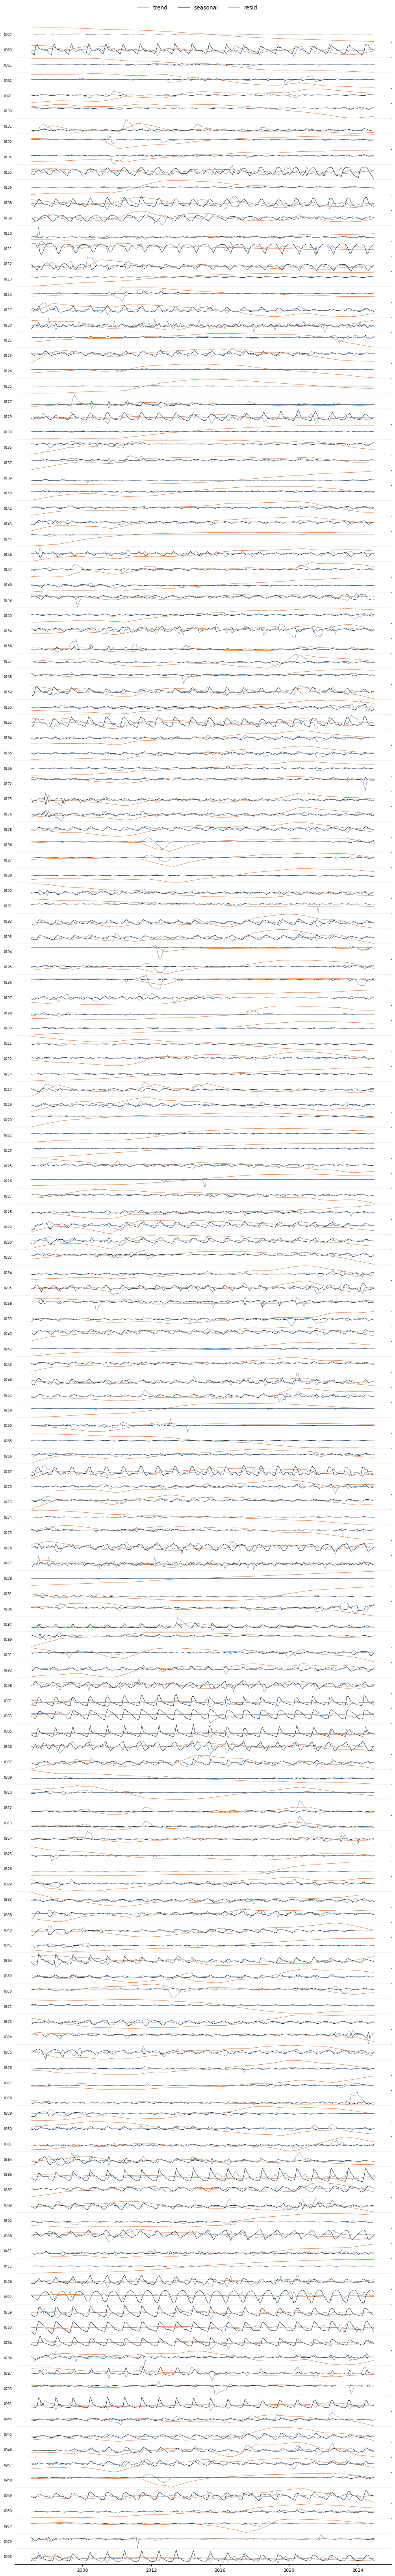

In [14]:
order = sorted(df_m.columns)

C = {"trend": colour_2, "seasonal": colour_1, "resid": colour_3}

n = len(order)
fig, axes = plt.subplots(n, 1, figsize=(11, n*0.4), sharex=True, sharey=False)

for ax, w in zip(axes, order):
    for comp in ("trend", "seasonal", "resid"):
        ax.plot(df_m.index, comps[w][comp], lw=0.6, color=C[comp])
    ax.set_ylabel(w, rotation=0, ha="right", va="center", fontsize=6)
    ax.set_yticks([])
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)

axes[-1].tick_params(labelsize=8)
handles = [plt.Line2D([], [], color=C[k], lw=1.5, label=k) for k in C]
fig.legend(handles=handles, ncol=3, frameon=False, loc="upper center")
fig.subplots_adjust(hspace=0, left=0.12, right=0.99, top=0.99, bottom=0.02)
plt.show()

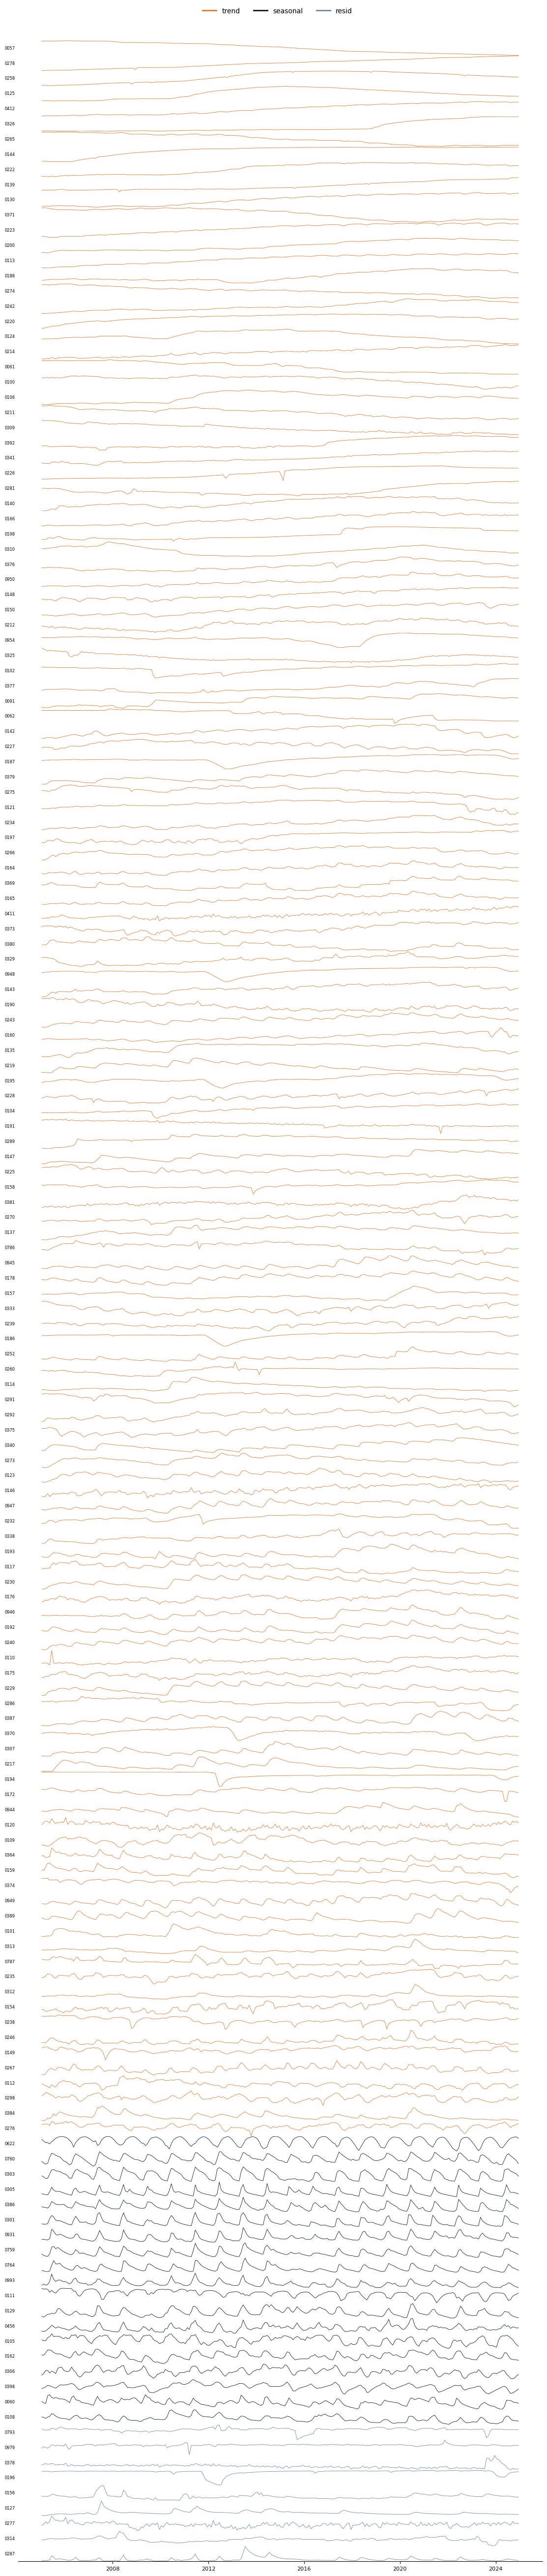

In [15]:
dom = frac.idxmax(axis=1)                          # dominant component per well

order, boundaries, cursor = [], [], 0
for comp in ("trend", "seasonal", "resid"):
    members = frac.loc[dom == comp, comp].sort_values(ascending=False).index
    order.extend(members)
    cursor += len(members)
    boundaries.append((comp, cursor, len(members)))

n = len(order)
fig, axes = plt.subplots(n, 1, figsize=(11, n*0.32), sharex=True, sharey=False)
C = {"trend": colour_2, "seasonal": colour_1, "resid": colour_3}

for ax, w in zip(axes, order):
    ax.plot(df_m.index, z[w], lw=0.6, color=C[dom[w]])   # color encodes the group
    ax.set_ylabel(w, rotation=0, ha="right", va="center", fontsize=6)
    ax.set_yticks([])
    ax.margins(y=0.02)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)


axes[-1].tick_params(labelsize=8)
axes[-1].spines["bottom"].set_visible(True)

handles = [plt.Line2D([], [], color=C[k], lw=2, label=k) for k in C]
fig.legend(handles=handles, ncol=3, frameon=False, loc="upper center",
           bbox_to_anchor=(0.5, 1.0), fontsize=10)

fig.subplots_adjust(hspace=0, left=0.02, right=0.99, top=0.985, bottom=0.02)
plt.show()

In [16]:
from matplotlib.backends.backend_pdf import PdfPages

/tmp/ipykernel_14482/3775404060.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


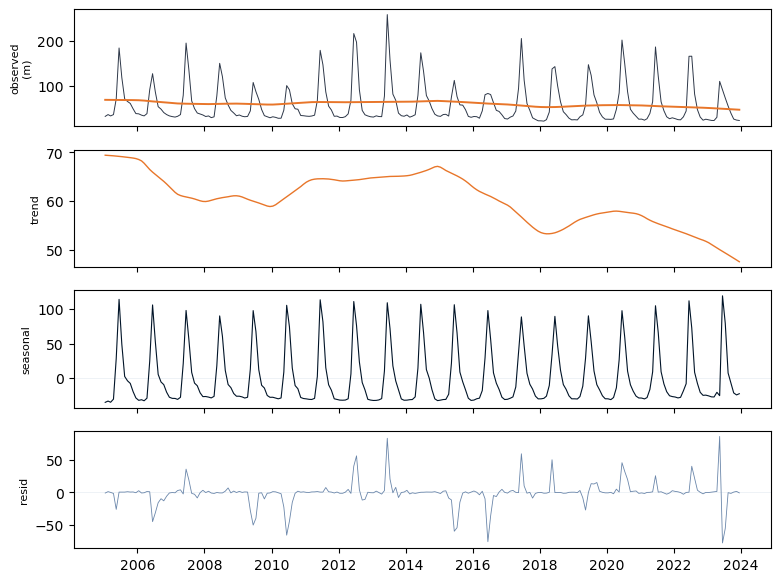

In [22]:
r = STL(brac['Flow'], period=12, robust=True).fit()
sd = brac['Flow'].std()
fit = r
comp = {"trend": (r.trend - r.trend.mean()) / sd,
        "seasonal": r.seasonal / sd,
        "resid": r.resid / sd}

fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)

axes[0].plot(brac.index, brac['Flow'], lw=0.7, color="#2d3748")
axes[0].plot(brac.index, r.trend, lw=1.4, color=C["trend"])   # fit over data
axes[0].set_ylabel("observed\n(m)", fontsize=8)

axes[1].plot(brac.index, r.trend, lw=1.0, color=C["trend"])
axes[1].set_ylabel("trend", fontsize=8)

axes[2].plot(brac.index, r.seasonal, lw=0.8, color=C["seasonal"])
axes[2].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
axes[2].set_ylabel("seasonal", fontsize=8)

axes[3].plot(brac.index, r.resid, lw=0.6, color=C["resid"])
axes[3].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
axes[3].set_ylabel("resid", fontsize=8)

fig.show()

/tmp/ipykernel_14482/911048639.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


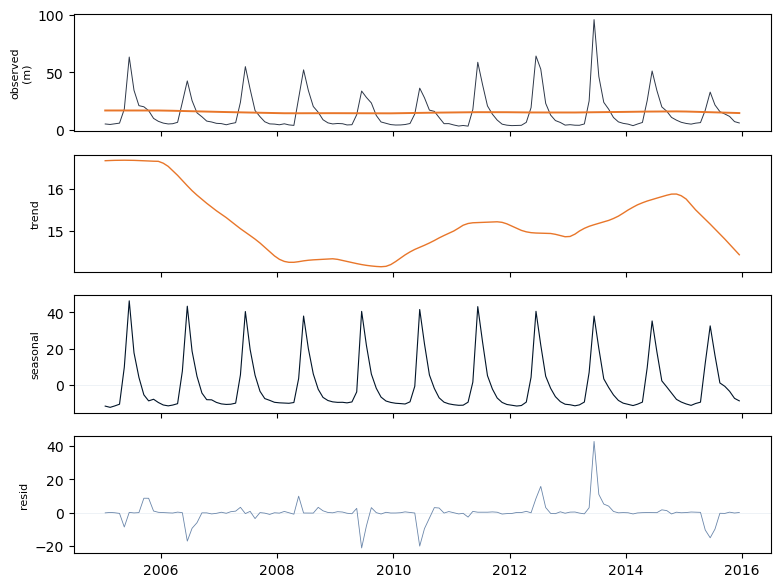

In [23]:
r = STL(krns['Flow'], period=12, robust=True).fit()
sd = krns['Flow'].std()
fit = r
comp = {"trend": (r.trend - r.trend.mean()) / sd,
        "seasonal": r.seasonal / sd,
        "resid": r.resid / sd}

fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)

axes[0].plot(krns.index, krns['Flow'], lw=0.7, color="#2d3748")
axes[0].plot(krns.index, r.trend, lw=1.4, color=C["trend"])   # fit over data
axes[0].set_ylabel("observed\n(m)", fontsize=8)

axes[1].plot(krns.index, r.trend, lw=1.0, color=C["trend"])
axes[1].set_ylabel("trend", fontsize=8)

axes[2].plot(krns.index, r.seasonal, lw=0.8, color=C["seasonal"])
axes[2].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
axes[2].set_ylabel("seasonal", fontsize=8)

axes[3].plot(krns.index, r.resid, lw=0.6, color=C["resid"])
axes[3].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
axes[3].set_ylabel("resid", fontsize=8)

fig.show()

In [ ]:
# dom = frac.idxmax(axis=1)
# C = {"trend": colour_2, "seasonal": colour_1, "resid": colour_3}

# # walk trend wells -> seasonal -> resid, purest first within each group
# order = []
# for comp in ("trend", "seasonal", "resid"):
#     order.extend(frac.loc[dom == comp, comp].sort_values(ascending=False).index)

# with PdfPages("stl_all_wells.pdf") as pdf:
#     for w in order:
#         r = fits[w]
#         fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)

#         axes[0].plot(df_m.index, df_m[w], lw=0.7, color="#2d3748")
#         axes[0].plot(df_m.index, r.trend, lw=1.4, color=C["trend"])   # fit over data
#         axes[0].set_ylabel("observed\n(m)", fontsize=8)

#         axes[1].plot(df_m.index, r.trend, lw=1.0, color=C["trend"])
#         axes[1].set_ylabel("trend", fontsize=8)

#         axes[2].plot(df_m.index, r.seasonal, lw=0.8, color=C["seasonal"])
#         axes[2].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
#         axes[2].set_ylabel("seasonal", fontsize=8)

#         axes[3].plot(df_m.index, r.resid, lw=0.6, color=C["resid"])
#         axes[3].axhline(0, lw=0.4, color="#e2e8f0", zorder=0)
#         axes[3].set_ylabel("resid", fontsize=8)

#         for ax in axes:
#             ax.tick_params(labelsize=7)
#             for s in ("top", "right"):
#                 ax.spines[s].set_visible(False)

#         f = frac.loc[w]
#         fig.suptitle(
#             f"{w}   ·   trend {f['trend']:.2f}   seasonal {f['seasonal']:.2f}   resid {f['resid']:.2f}"
#             f"   ·   dominant: {dom[w]}",
#             fontsize=10, color=C[dom[w]], y=0.98)
#         fig.subplots_adjust(hspace=0.12, left=0.10, right=0.98, top=0.93, bottom=0.06)

#         pdf.savefig(fig)
#         plt.close(fig)

### Inter-annual variations on trend and residual components of STL

In [25]:
iav_trend = pd.Series({w: fits[w].trend.std() for w in df_m.columns})

In [26]:
resid_ann = pd.DataFrame({w: fits[w].resid for w in df_m.columns}).resample("YS").mean()
iav_anom = resid_ann.std()

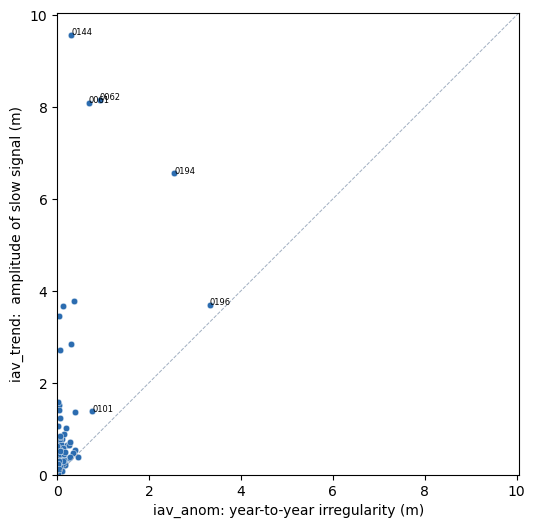

In [27]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(iav_anom, iav_trend, s=22, c="#2b6cb0", edgecolor="w", lw=0.3)

lim = max(iav_trend.max(), iav_anom.max()) * 1.05
ax.plot([0, lim], [0, lim], lw=0.7, ls="--", color="#a0aec0")   # y = x
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")
ax.set_xlabel("iav_anom: year-to-year irregularity (m)")
ax.set_ylabel("iav_trend:  amplitude of slow signal (m)")

for w in iav_trend.nlargest(4).index.union(iav_anom.nlargest(4).index):
    ax.annotate(w, (iav_anom[w], iav_trend[w]), fontsize=6)

## Harmonic Regression

In [28]:
import statsmodels.api as sm

In [29]:
t = np.arange(len(df_m))
X = sm.add_constant(pd.DataFrame({
    "t":   t,
    "cos": np.cos(2*np.pi*t/12),
    "sin": np.sin(2*np.pi*t/12),
}, index=df_m.index))

In [30]:
X

,const,t,cos,sin
date,,,,
2005-01-15,1.0,0,1.000000e+00,0.000000
2005-02-15,1.0,1,8.660254e-01,0.500000
2005-03-15,1.0,2,5.000000e-01,0.866025
2005-04-15,1.0,3,6.123234e-17,1.000000
2005-05-15,1.0,4,-5.000000e-01,0.866025
...,...,...,...,...
2024-08-15,1.0,235,-8.660254e-01,-0.500000
2024-09-15,1.0,236,-5.000000e-01,-0.866025
2024-10-15,1.0,237,-1.371914e-14,-1.000000


- Jan - 0
- Dec - 2*pi = 6.2

In [31]:
it, ia, ib = (X.columns.get_loc(k) for k in ("t", "cos", "sin"))
R = np.zeros((2, X.shape[1]))
R[0, ia] = 1
R[1, ib] = 1     # H0: a = b = 0

In [32]:
print(it, ia, ib)

1 2 3


In [33]:
R

array([[0., 0., 1., 0.],
       [0., 0., 0., 1.]])

- df_m[w]: per well time-series (dependent variable)
- X: 1 intercept (`const`) + 3 regressors (`t`, `cos`, `sin`)
- rho: order of autoregressive covariance

Fitting:
$$y_t = \beta_0 + \beta_1 t + \beta_2\cos\!\Big(\tfrac{2\pi t}{12}\Big) + \beta_3\sin\!\Big(\tfrac{2\pi t}{12}\Big) + \varepsilon_t​
$$

Plain OLS assumes $\varepsilon_t$ are i.i.d. noise. GLSAR instead assumes the errors themselves follow an AR(1) process:
$$\varepsilon_t = \rho\,\varepsilon_{t-1} + \eta_t, \qquad \eta_t \sim \text{i.i.d. noise}$$

In [34]:
rows = {}
for w in df_m.columns:
    mod = sm.GLSAR(df_m[w].values, X.values, rho=1)
    res = mod.iterative_fit(maxiter=10)
    a, b = res.params[ia], res.params[ib]
    seas = a*np.cos(2*np.pi*t/12) + b*np.sin(2*np.pi*t/12)
    rows[w] = {
        "slope_m_yr": res.params[it] * 12,
        "slope_se":   res.bse[it] * 12,
        "amp_pp":     2*np.hypot(a, b),                    # peak-to-peak, metres
        "phase_rad":  np.arctan2(b, a),
        "peak_month": pd.Series(seas, index=df_m.index)
                        .groupby(df_m.index.month).mean().idxmax(),
        "rho":        mod.rho[0],
        "resid_sd":   np.std(res.resid),
        "seas_p":     float(res.f_test(R).pvalue),
    }
harm = pd.DataFrame(rows).T
harm["snr"] = harm["amp_pp"] / harm["resid_sd"]

<Axes: >

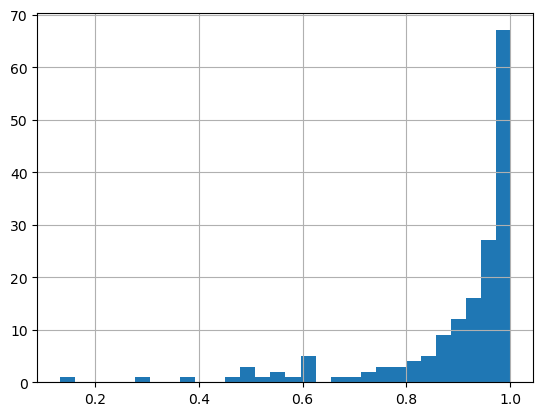

In [35]:
harm['rho'].hist(bins=30)

In [36]:
harm

,slope_m_yr,slope_se,amp_pp,phase_rad,peak_month,rho,resid_sd,seas_p,snr
0057,-0.631759,0.018736,0.087128,-0.611503,12.0,0.974444,0.533395,2.067698e-07,0.163347
0060,-0.032201,0.010987,0.578646,3.107560,7.0,0.724525,0.385398,2.969742e-08,1.501422
0061,-1.463001,0.163698,0.228073,-2.911870,7.0,0.974582,2.072352,2.273572e-01,0.110055
0062,-1.422459,0.191953,0.209142,1.237499,3.0,0.943378,3.016890,8.364506e-01,0.069324
0091,-0.073320,0.093640,0.164257,-1.294297,11.0,0.993401,1.026197,3.272771e-14,0.160063
...,...,...,...,...,...,...,...,...,...
0949,0.026547,0.012780,0.518545,-2.817836,8.0,0.878276,0.293402,1.344809e-19,1.767356
0950,0.036573,0.007383,0.053848,2.668569,6.0,0.963979,0.093828,7.999152e-09,0.573903
0954,0.084398,0.249573,0.059928,1.777170,4.0,0.995796,0.944782,1.955229e-01,0.063430
0979,0.001758,0.001211,0.059765,-0.837816,11.0,0.289673,0.080429,5.471754e-03,0.743079


Text(5, 5, '0091')

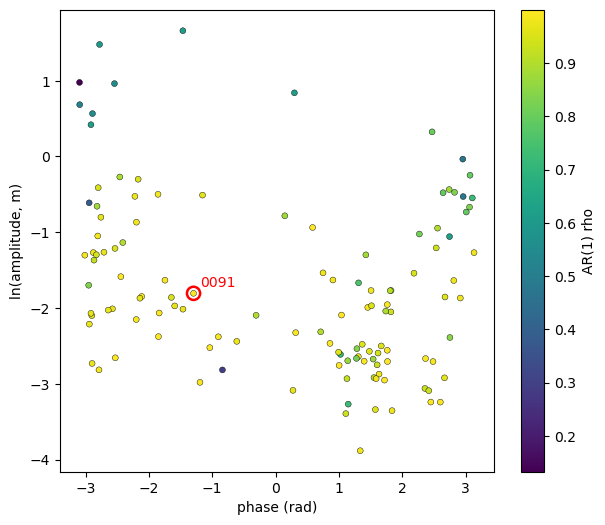

In [37]:
sig = harm[harm["seas_p"] < 0.01].copy()          # keep only wells with a real cycle
sig["ln_amp"] = np.log(sig["amp_pp"])

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(sig["phase_rad"], sig["ln_amp"], s=18, c=sig["rho"],
                 cmap="viridis", edgecolor="k", lw=0.3)
plt.colorbar(sc, label="AR(1) rho")
ax.set_xlabel("phase (rad)"); ax.set_ylabel("ln(amplitude, m)")

w = "0091"
ax.scatter(harm.loc[w,"phase_rad"], np.log(harm.loc[w,"amp_pp"]),
           s=90, facecolor="none", edgecolor="red", lw=1.8)
ax.annotate(w, (harm.loc[w,"phase_rad"], np.log(harm.loc[w,"amp_pp"])),
            xytext=(5,5), textcoords="offset points", color="red")

In [38]:
sig

,slope_m_yr,slope_se,amp_pp,phase_rad,peak_month,rho,resid_sd,seas_p,snr,ln_amp
0057,-0.631759,0.018736,0.087128,-0.611503,12.0,0.974444,0.533395,2.067698e-07,0.163347,-2.440373
0060,-0.032201,0.010987,0.578646,3.107560,7.0,0.724525,0.385398,2.969742e-08,1.501422,-0.547065
0091,-0.073320,0.093640,0.164257,-1.294297,11.0,0.993401,1.026197,3.272771e-14,0.160063,-1.806326
0101,-0.253429,0.119908,0.662752,-2.799433,8.0,0.947502,1.826195,5.164985e-03,0.362914,-0.411354
0102,0.055417,0.021333,0.056558,1.635130,4.0,0.980799,0.268986,1.109791e-04,0.210262,-2.872495
...,...,...,...,...,...,...,...,...,...,...
0947,0.025246,0.039366,0.448505,-2.757230,8.0,0.963403,0.474934,4.392742e-18,0.944352,-0.801836
0949,0.026547,0.012780,0.518545,-2.817836,8.0,0.878276,0.293402,1.344809e-19,1.767356,-0.656728
0950,0.036573,0.007383,0.053848,2.668569,6.0,0.963979,0.093828,7.999152e-09,0.573903,-2.921584
0979,0.001758,0.001211,0.059765,-0.837816,11.0,0.289673,0.080429,5.471754e-03,0.743079,-2.817339


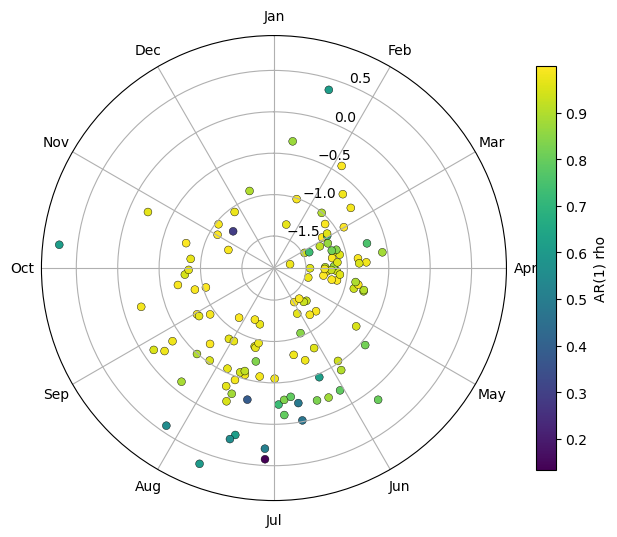

In [39]:
sig = harm[harm["seas_p"] < 0.01].copy()
sig["peak_t"] = (12 * sig["phase_rad"] / (2*np.pi)) % 12   # continuous, 0 = Jan 1

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={"projection": "polar"})
sc = ax.scatter(2*np.pi*sig["peak_t"]/12, np.log10(sig["amp_pp"]),
                s=32, c=sig["rho"], cmap="viridis", edgecolor="k", lw=0.3)
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_xticks(np.arange(12)*2*np.pi/12)
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_rlim(np.log10(sig["amp_pp"]).min()-0.2, np.log10(sig["amp_pp"]).max()+0.2)
plt.colorbar(sc, label="AR(1) rho", shrink=0.7)

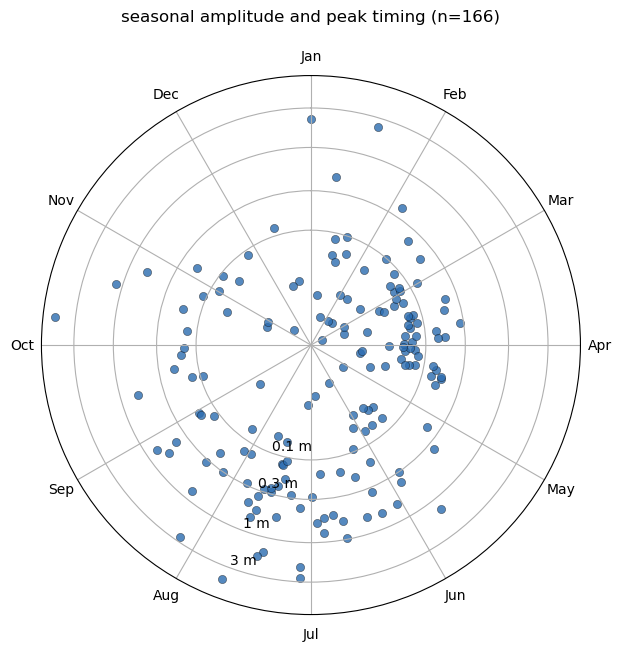

In [40]:
angle = harm["phase_rad"] % (2*np.pi)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
ax.scatter(angle, np.log10(harm["amp_pp"]), s=35, c="#2b6cb0",
           edgecolor="k", lw=0.3, alpha=0.8)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_xticks(np.arange(12) * 2*np.pi/12)
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])

ticks = [0.1, 0.3, 1, 3]
ax.set_rticks(np.log10(ticks))
ax.set_yticklabels([f"{v} m" for v in ticks])
ax.set_rlabel_position(200)
ax.set_title(f"seasonal amplitude and peak timing (n={len(harm)})", pad=20)
plt.show()

In [44]:
coords.rename(columns={'latitude': 'lat', 'longitude': 'lon'}, inplace=True)

In [ ]:
out = harm[["amp_pp", "phase_rad", "peak_month", "rho", "snr", "seas_p"]].copy()
out["seas_sig"] = out["seas_p"] < 0.01
out["phase_deg"] = ((12 * out["phase_rad"] / (2*np.pi)) % 12) / 12 * 360
out = out.join(coords[["lat", "lon"]])
out.index.name = "station"
# out.round(4).to_csv("harmonic_regression_features.csv")

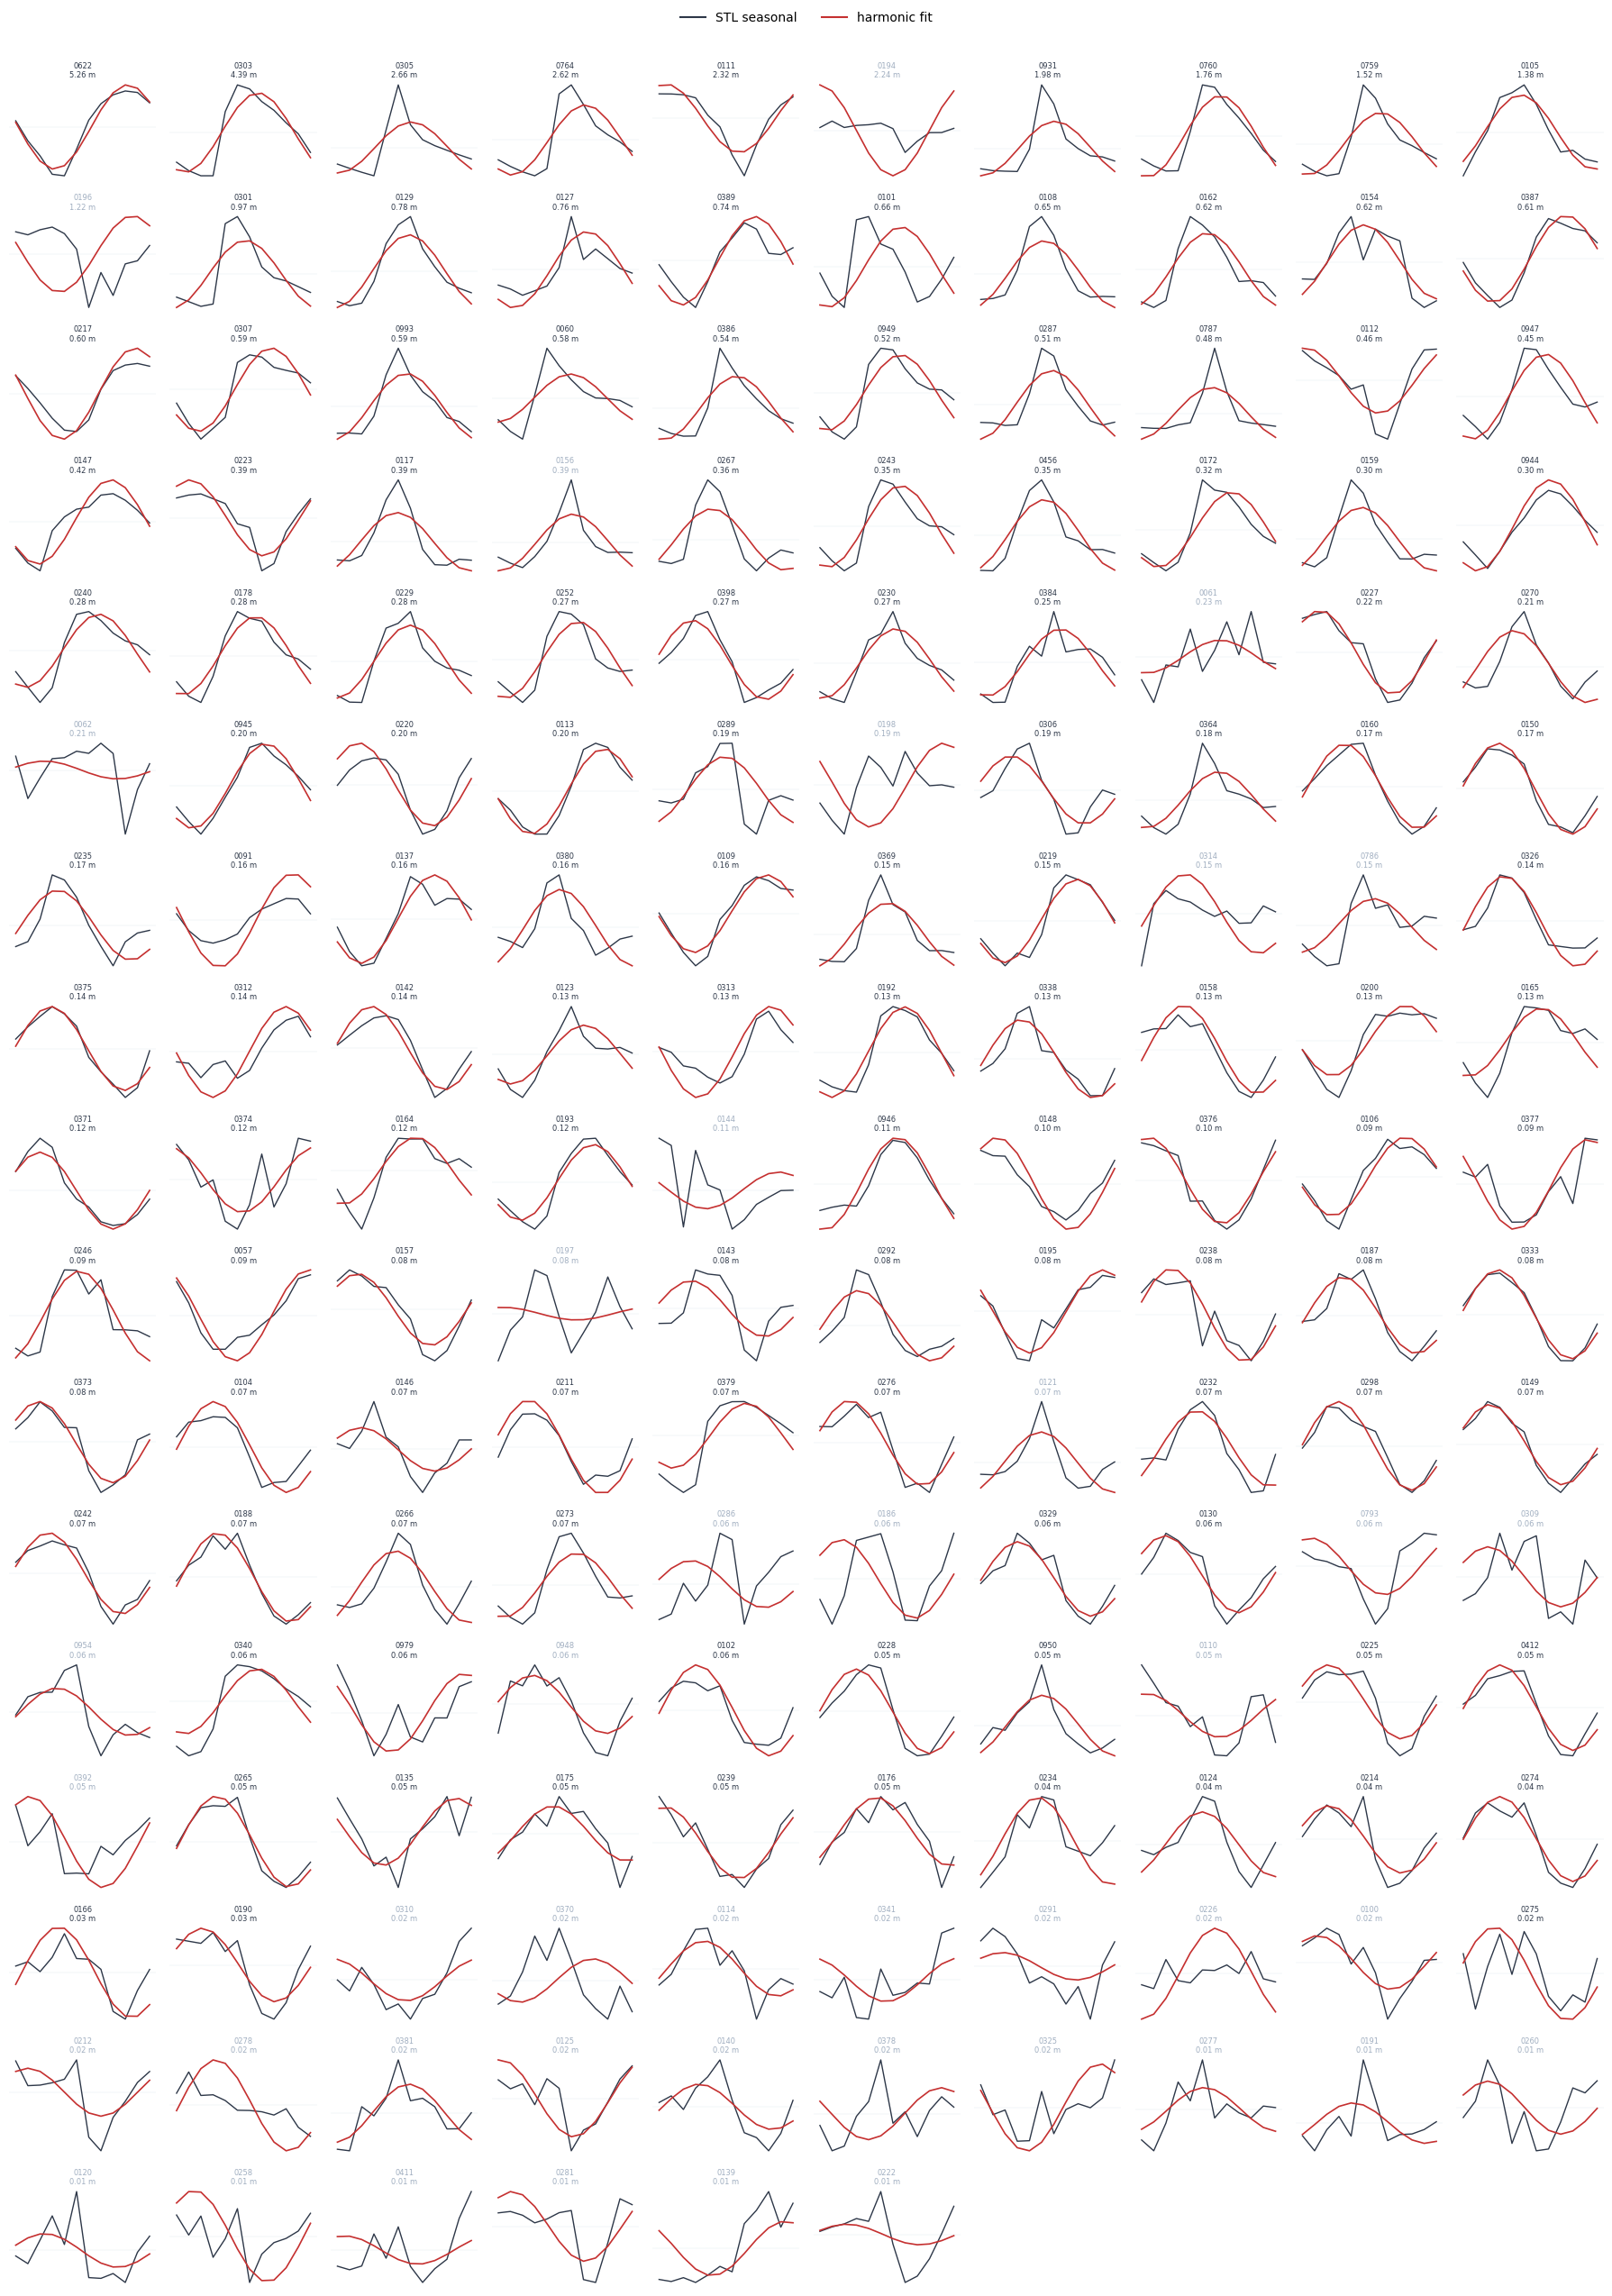

In [ ]:
import math

t = np.arange(len(df_m))
order = harm.sort_values("amp_pp", ascending=False).index

n = len(order)
ncols = 10
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*1.8, nrows*1.5))
axes = axes.flatten()

for ax, w in zip(axes, order):
    # STL seasonal, averaged across the 20 years -> mean annual cycle
    s = fits[w].seasonal
    stl_cycle = s.groupby(s.index.month).mean()

    # harmonic fit, rebuilt from amp_pp and phase, folded the same way
    A, phi = harm.loc[w, "amp_pp"] / 2, harm.loc[w, "phase_rad"]
    fit = pd.Series(A * np.cos(2*np.pi*t/12 - phi), index=df_m.index)
    fit_cycle = fit.groupby(df_m.index.month).mean()

    ax.plot(stl_cycle.index, stl_cycle.values, lw=1.0, color="#2d3748")
    ax.plot(fit_cycle.index, fit_cycle.values, lw=1.2, color="#c53030")
    ax.axhline(0, lw=0.3, color="#e2e8f0", zorder=0)

    ok = harm.loc[w, "seas_p"] < 0.01
    ax.set_title(f"{w}\n{harm.loc[w, 'amp_pp']:.2f} m", fontsize=6, pad=2,
                 color="#2d3748" if ok else "#a0aec0")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ("top", "right", "left", "bottom"):
        ax.spines[sp].set_visible(False)

for ax in axes[n:]:
    ax.axis("off")

fig.legend(handles=[plt.Line2D([], [], color="#2d3748", lw=1.5, label="STL seasonal"),
                    plt.Line2D([], [], color="#c53030", lw=1.5, label="harmonic fit")],
           ncol=2, frameon=False, loc="upper center")
plt.tight_layout(rect=[0, 0, 1, 0.98])
# fig.savefig("harmonic_fit_examples.pdf", dpi=400, bbox_inches="tight")
plt.show()

## Seasonal MK

In [48]:
import pymannkendall as mk

explicity show seasonal correlation, to justify using this method

In [49]:
rows = {}
for w in df_m.columns:
    r = mk.correlated_seasonal_test(df_m[w].values, period=12)
    rows[w] = {"tau": r.Tau, "slope_m_yr": r.slope, "p": r.p, "verdict": r.trend}

smk = pd.DataFrame(rows).T
smk[["tau", "slope_m_yr", "p"]] = smk[["tau", "slope_m_yr", "p"]].astype(float)

print(smk["verdict"].value_counts())

verdict
increasing    73
no trend      50
decreasing    43
Name: count, dtype: int64


In [50]:
sen = smk.sort_values("slope_m_yr")
print("strongest declines:\n", sen[["slope_m_yr", "tau", "p"]].head(5))
print("\nstrongest rises:\n", sen[["slope_m_yr", "tau", "p"]].tail(5))
print(f"\n{(smk['p'] < 0.05).sum()} of {len(smk)} 'significant' at p<0.05")

strongest declines:
       slope_m_yr       tau             p
0061   -1.365273 -0.903509  1.958160e-08
0062   -1.335943 -0.810526  3.775539e-07
0194   -0.742030 -0.328947  3.039111e-02
0057   -0.590100 -0.992982  9.124306e-10
0309   -0.217903 -0.920175  9.828199e-09

strongest rises:
       slope_m_yr       tau             p
0326    0.421087  0.939474  5.660944e-09
0197    0.440817  0.806140  2.080077e-07
0223    0.474560  0.918421  8.447794e-09
0198    0.515238  0.676316  2.027925e-05
0144    0.847642  0.859649  7.635558e-08

116 of 166 'significant' at p<0.05


In [51]:
smk.sort_values("slope_m_yr")

,tau,slope_m_yr,p,verdict
0061,-0.903509,-1.365273,1.958160e-08,decreasing
0062,-0.810526,-1.335943,3.775539e-07,decreasing
0194,-0.328947,-0.742030,3.039111e-02,decreasing
0057,-0.992982,-0.590100,9.124306e-10,decreasing
0309,-0.920175,-0.217903,9.828199e-09,decreasing
...,...,...,...,...
0326,0.939474,0.421087,5.660944e-09,increasing
0197,0.806140,0.440817,2.080077e-07,increasing
0223,0.918421,0.474560,8.447794e-09,increasing
0198,0.676316,0.515238,2.027925e-05,increasing


In [64]:
smk.index = pd.to_numeric(smk.index, errors='coerce')
smk

,tau,slope_m_yr,p,verdict
57,-0.992982,-0.590100,9.124306e-10,decreasing
60,-0.377193,-0.034794,1.158076e-03,decreasing
61,-0.903509,-1.365273,1.958160e-08,decreasing
62,-0.810526,-1.335943,3.775539e-07,decreasing
91,0.650877,0.097235,2.676208e-05,increasing
...,...,...,...,...
949,0.390351,0.030953,5.302985e-03,increasing
950,0.796491,0.038894,5.393499e-07,increasing
954,0.077193,0.017541,6.193841e-01,no trend
979,0.012281,0.000134,9.032354e-01,no trend


In [65]:
mk_res = pd.merge(coords, smk, left_index=True, right_index=True)

In [94]:
mk_res

,lat,lon,tau,slope_m_yr,p,verdict
60,57.237791,-111.449408,-0.377193,-0.034794,1.158076e-03,decreasing
192,54.606251,-110.252970,0.189474,0.007984,1.858555e-01,no trend
301,50.950088,-115.153928,-0.276316,-0.012168,1.515859e-02,decreasing
164,53.503681,-112.112588,0.661404,0.056784,2.353134e-05,increasing
154,53.287000,-110.017167,0.494737,0.107228,1.226957e-04,increasing
...,...,...,...,...,...,...
242,54.060985,-110.408516,0.840351,0.081895,1.680354e-07,increasing
381,58.995364,-117.656388,0.242982,0.004146,1.031165e-01,no trend
220,50.844665,-113.466857,0.378947,0.152133,1.817279e-02,increasing
226,51.788498,-110.501592,0.797368,0.070928,6.189514e-07,increasing


In [68]:
smk.loc[154]

tau             0.494737
slope_m_yr      0.107228
p               0.000123
verdict       increasing
Name: 154, dtype: object

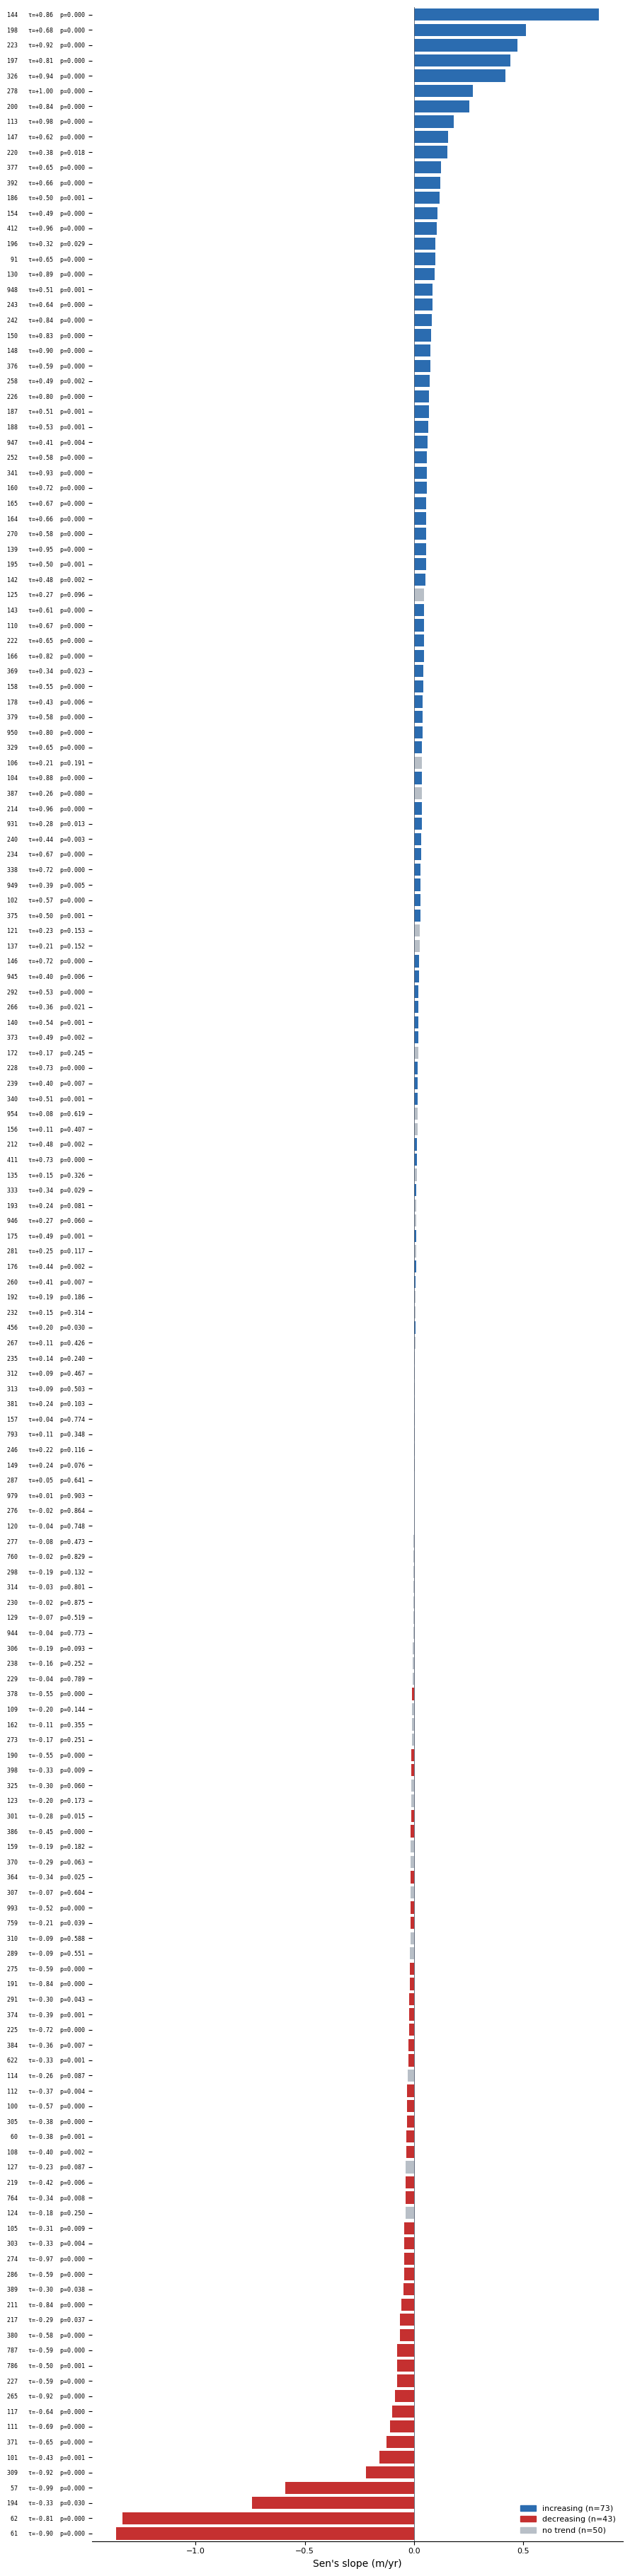

In [69]:
d = smk.sort_values("slope_m_yr")          # ascending: declines at bottom, rises at top

colors = {"increasing": "#2b6cb0", "decreasing": "#c53030", "no trend": "#b8bfc7"}
bar_c = [colors[v] for v in d["verdict"]]

# station ID + stats folded into the y-label, so the bar itself stays a clean slope
labels = [f"{w}   τ={d.loc[w,'tau']:+.2f}  p={d.loc[w,'p']:.3f}" for w in d.index]

n = len(d)
fig, ax = plt.subplots(figsize=(9, n*0.22))
ax.barh(range(n), d["slope_m_yr"], color=bar_c, edgecolor="none")
ax.axvline(0, lw=0.6, color="#4a5568")

ax.set_yticks(range(n))
ax.set_yticklabels(labels, fontsize=6, fontfamily="monospace")
ax.set_ylim(-0.5, n-0.5)
ax.set_xlabel("Sen's slope (m/yr)")
ax.tick_params(axis="x", labelsize=8)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)

# legend with counts
from matplotlib.patches import Patch
counts = d["verdict"].value_counts()
handles = [Patch(color=colors[v], label=f"{v} (n={counts.get(v,0)})")
           for v in ("increasing", "decreasing", "no trend")]
ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=8)

plt.tight_layout()
# fig.savefig("smk_results.pdf", bbox_inches="tight")
plt.show()

In [72]:
df_m.columns = df_m.columns.astype(int)

In [74]:
order = smk.sort_values("slope_m_yr").index          # declines first
tnum = np.arange(len(df_m))                          # month counter for the line
tmed = np.median(tnum)

vcolor = {"increasing": "#2b6cb0", "decreasing": "#c53030", "no trend": "#718096"}

with PdfPages("smk_per_well.pdf") as pdf:
    for w in order:
        y = df_m[w]
        slope_mo = smk.loc[w, "slope_m_yr"] / 12       # back to per-month for plotting
        ymed = y.median()
        line = ymed + slope_mo * (tnum - tmed)         # Sen line through the median point

        v = smk.loc[w, "verdict"]
        fig, ax = plt.subplots(figsize=(9, 3.2))
        ax.plot(df_m.index, y, lw=0.7, color="#2d3748")
        ax.plot(df_m.index, line, lw=1.8, color=vcolor[v])

        ax.set_title(
            f"{w}    Sen {smk.loc[w,'slope_m_yr']:+.3f} m/yr    "
            f"τ={smk.loc[w,'tau']:+.2f}    p={smk.loc[w,'p']:.3f}    {v}",
            fontsize=10, color=vcolor[v])
        ax.set_ylabel("WLE (m)", fontsize=8)
        ax.tick_params(labelsize=8)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)

        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

## BEAST: Bayesian Change-Point Detection and Time-Series Decomposition

In [45]:
import Rbeast as rb

In [46]:
w = "06ACG040"
y = df_m[w].values

In [47]:
o = rb.beast(
    y,
    start=[2005, 1, 1],
    deltat="1 month",
    period="1 year",                  # seasonal cycle length
    season="harmonic",                # harmonic seasonal model
    tcp_minmax=[0,5],
    scp_minmax=[0,5]
)

Exception ignored in PyObject_HasAttrString(); consider using PyObject_HasAttrStringWithError(), PyObject_GetOptionalAttrString() or PyObject_GetAttrString():
Traceback (most recent call last):
  File "/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/beast.py", line 498, in beast
    o = cbeast.Rbeast('beast_'+method,Y, metadata, prior, mcmc, extra) 
SystemError: /home/conda/feedstock_root/build_artifacts/python-split_1765018748003/work/Objects/dictobject.c:4167: bad argument to internal function


INFO: Your metadata$startTime=[2005,1,1] is interpreted as 2005/01/01 (Year/Month/Day) and converted to a decimal year of 2005. If not making sense, supply a correct start time using one of the following for startTime:  
(1) a numeric scalar (e.g., 2002.33)
(2) a vector of two values (Year, Month) (e.g., c(2002,4) in R, [2002,4] in Matlab/Python) 
(3) a vector of three values (Year, Month, Day) (e.g., c(2002,4,15) in R,  [2002,4,15] in Matlab/Python)
(4) a date string (e.g., "2002-4-15", "2002/04/15", or "2002/4")
(5) a datenum as a list/struct variable (e.g., list(datenum=12523, origin='R') or struct('datenum', 731321, 'origin','matlab')


Model fitted:  Y =  trend + season + error 

INFO: To supress messages, set print_param/print_warning/print_progresss = 0 in beast() and beast_irreg()
INFO: To supress messages, Set extra.printParameter/printWarning/printProgress = 0 in beast123()
INFO: To supress all messaages, set quiet=1 in beast() and beast_irreg() or extra.quiet=1 in beast123()

/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/plotbeast.py:1015: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(<Figure size 640x480 with 9 Axes>,
 array([<Axes: xlabel='[]', ylabel='Y'>,
        <Axes: xlabel='[]', ylabel='season'>,
        <Axes: xlabel='[]', ylabel='Pr(scp)'>,
        <Axes: xlabel='[]', ylabel='sOrder'>,
        <Axes: xlabel='[]', ylabel='trend'>,
        <Axes: xlabel='[]', ylabel='Pr(tcp)'>,
        <Axes: xlabel='[]', ylabel='tOrder'>,
        <Axes: xlabel='[]', ylabel='slpsgn'>,
        <Axes: xlabel='time', ylabel='error'>], dtype=object))

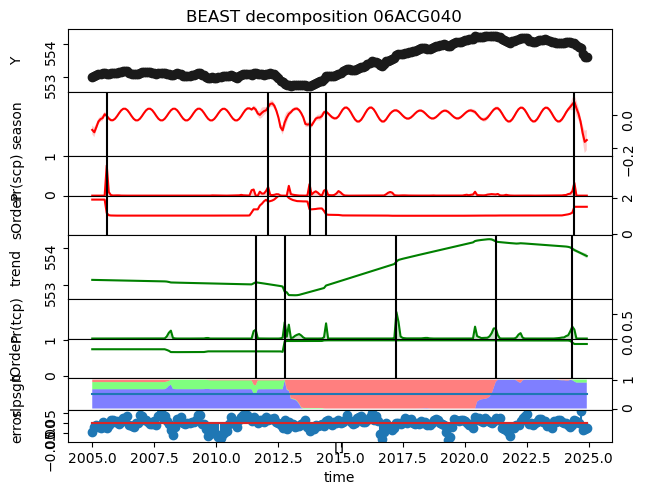

In [48]:
rb.plot(o, title=f"BEAST decomposition {w}")

In [49]:
print(o)

Object of 10 field(s):

 time        : [240 float32] 
 data        : [240 float32] 
 marg_lik    : -7.68631 
 R2          : 0.166667 
 RMSE        : 0.0247273 
 sig2        : 0.0010885 
 trend       : [ 1 object with 18 fields] 
               ncp            : 4.99863 
               ncp_median     : 5 
               ncp_mode       : 5 
               ncp_pct90      : 5 
               ncp_pct10      : 5 
               ncpPr          : [6 float32] 
               cpOccPr        : [240 float32] 
               order          : [240 float32] 
               cp             : [5 float32] 
               cpPr           : [5 float32] 
               cpAbruptChange : [5 float32] 
               cpCI           : [5x2 float32] 
               Y              : [240 float32] 
               SD             : [240 float32] 
               slp            : [240 float32] 
               slpSD          : [240 float32] 
               slpSgnPosPr    : [240 float32] 
               slpSgnZeroPr   : [2

In [50]:
# trend changepoints: probability at each time, and the most likely locations
tcp_prob = o.trend.cpOccPr            # Pr(trend changepoint) at each month
tcp_times = o.trend.cp                # most probable changepoint positions (years)
tcp_n = o.trend.ncp_mode              # most likely NUMBER of trend changepoints

In [51]:
# seasonal changepoints: when the CYCLE itself shifts (amplitude/shape)
scp_prob = o.season.cpOccPr
scp_times = o.season.cp

In [52]:
print(f"most likely # trend changepoints: {tcp_n}")
print(f"trend changepoint times: {tcp_times[~np.isnan(tcp_times)]}")

most likely # trend changepoints: [5.]
trend changepoint times: [2017.2513 2012.7513 2024.3347 2021.2513 2011.5847]


In [53]:
# network-level: does any well have a confident, datable break?
peak_prob = np.nanmax(o.trend.cpOccPr)
peak_time = o.trend.cp[0]             # highest-probability changepoint

In [54]:
peak_prob, peak_time

(np.float32(0.533375), np.float32(2017.2513))

Exception ignored in PyObject_HasAttrString(); consider using PyObject_HasAttrStringWithError(), PyObject_GetOptionalAttrString() or PyObject_GetAttrString():
Traceback (most recent call last):
  File "/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/beast.py", line 498, in beast
    o = cbeast.Rbeast('beast_'+method,Y, metadata, prior, mcmc, extra) 
SystemError: /home/conda/feedstock_root/build_artifacts/python-split_1765018748003/work/Objects/dictobject.c:4167: bad argument to internal function


INFO: Your metadata$startTime=[2005,1,1] is interpreted as 2005/01/01 (Year/Month/Day) and converted to a decimal year of 2005. If not making sense, supply a correct start time using one of the following for startTime:  
(1) a numeric scalar (e.g., 2002.33)
(2) a vector of two values (Year, Month) (e.g., c(2002,4) in R, [2002,4] in Matlab/Python) 
(3) a vector of three values (Year, Month, Day) (e.g., c(2002,4,15) in R,  [2002,4,15] in Matlab/Python)
(4) a date string (e.g., "2002-4-15", "2002/04/15", or "2002/4")
(5) a datenum as a list/struct variable (e.g., list(datenum=12523, origin='R') or struct('datenum', 731321, 'origin','matlab')


Model fitted:  Y =  trend + season + error 

INFO: To supress messages, set print_param/print_warning/print_progresss = 0 in beast() and beast_irreg()
INFO: To supress messages, Set extra.printParameter/printWarning/printProgress = 0 in beast123()
INFO: To supress all messaages, set quiet=1 in beast() and beast_irreg() or extra.quiet=1 in beast123()

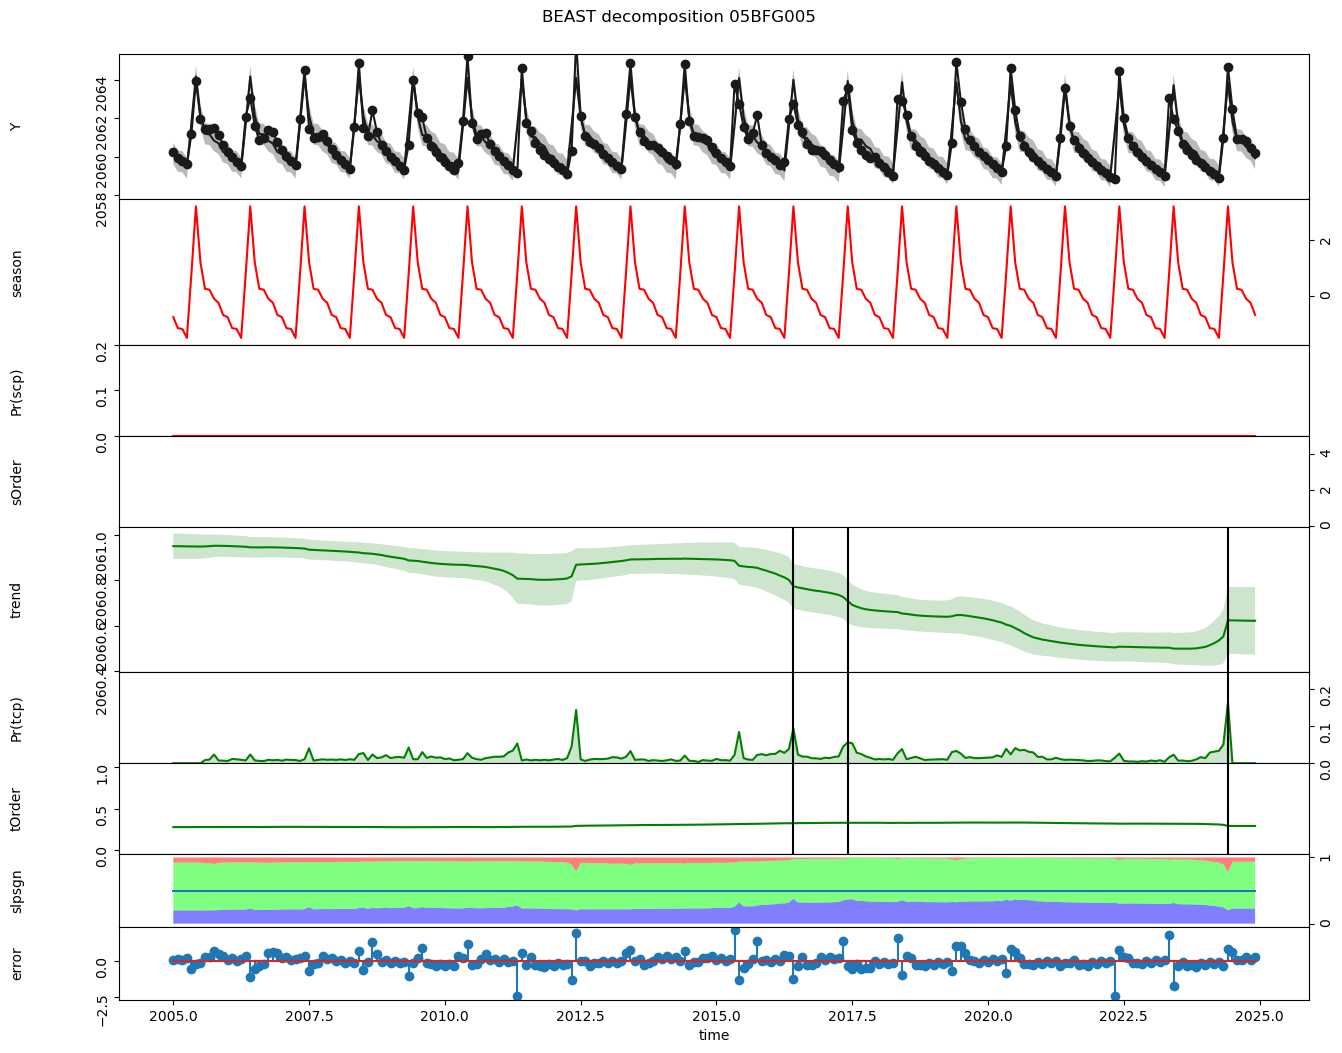

In [55]:
w ="05BFG005"
y = df_m[w].values

o = rb.beast(
    y,
    start=[2005, 1, 1],
    deltat="1 month",
    period="1 year",                  # seasonal cycle length
    season="harmonic",                # harmonic seasonal model
)

rb.plot(o, title=f"BEAST decomposition {w}")
fig = plt.gcf()
fig.set_size_inches(14, 11)

Exception ignored in PyObject_HasAttrString(); consider using PyObject_HasAttrStringWithError(), PyObject_GetOptionalAttrString() or PyObject_GetAttrString():
Traceback (most recent call last):
  File "/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/beast.py", line 498, in beast
    o = cbeast.Rbeast('beast_'+method,Y, metadata, prior, mcmc, extra) 
SystemError: /home/conda/feedstock_root/build_artifacts/python-split_1765018748003/work/Objects/dictobject.c:4167: bad argument to internal function


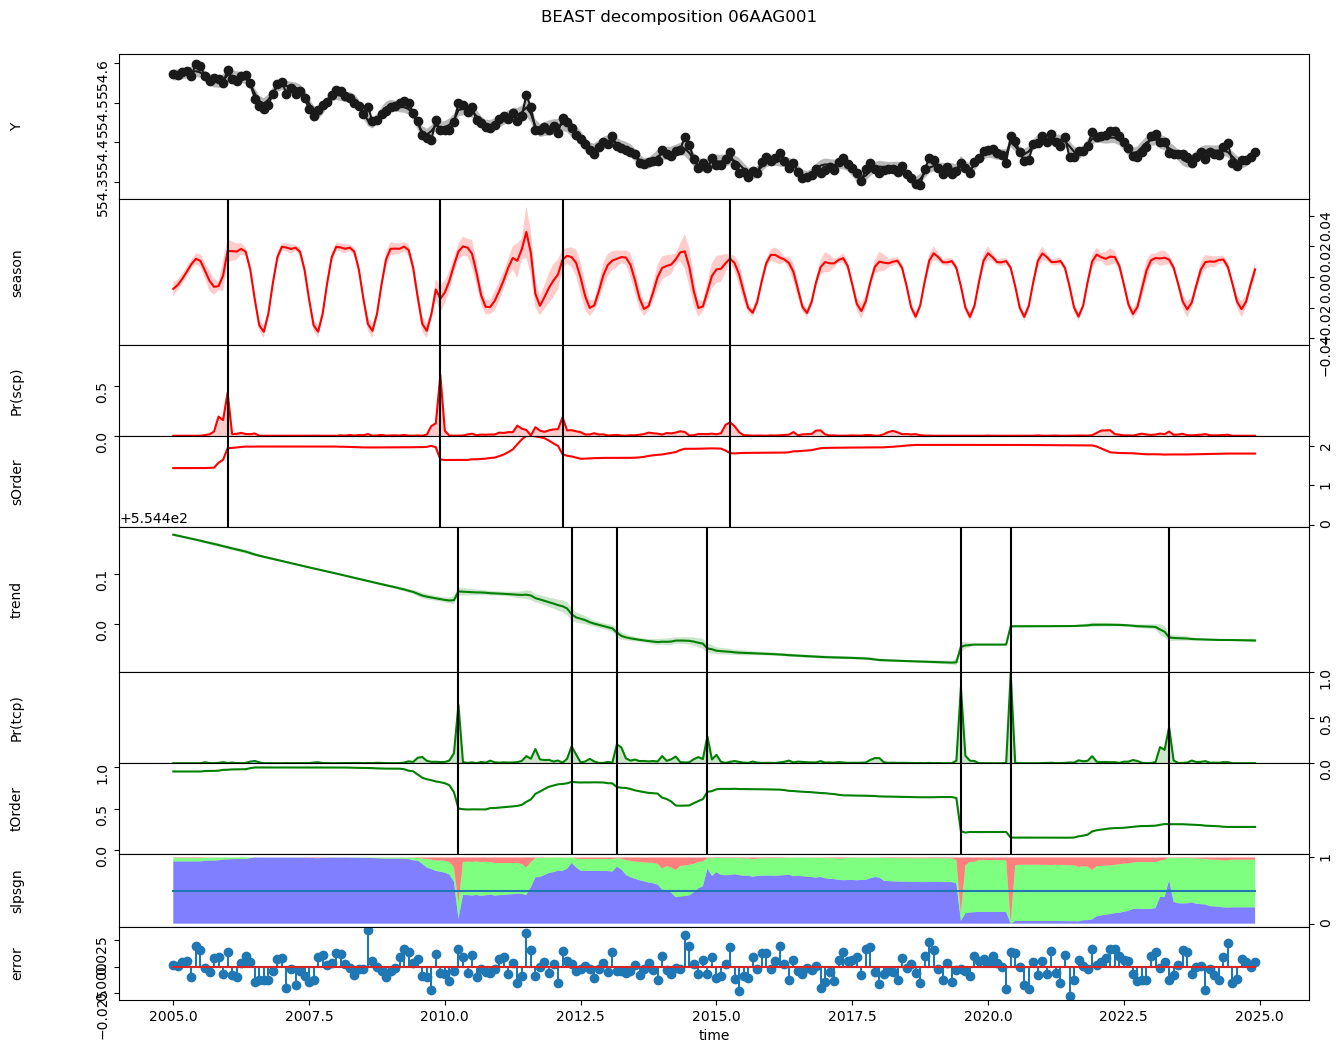

In [56]:
w ="06AAG001"
y = df_m[w].values

o = rb.beast(
    y,
    start=[2005, 1, 1],
    deltat="1 month",
    period="1 year",                  # seasonal cycle length
    season="harmonic",                # harmonic seasonal model
    tcp_minmax=[0,10],
    scp_minmax=[0,10],
    print_progress=False, print_options=False, quiet=True,
)

rb.plot(o, title=f"BEAST decomposition {w}")
fig = plt.gcf()
fig.set_size_inches(14, 11)

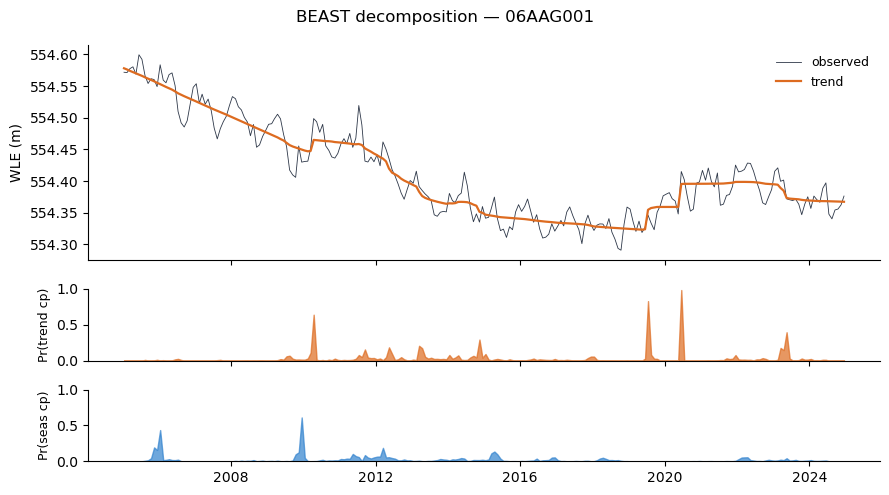

In [57]:
t = df_m.index
fig, ax = plt.subplots(3, 1, figsize=(9, 5), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1, 1]})

# 1. observed + fitted trend
ax[0].plot(t, df_m[w].values, lw=0.6, color="#2d3748", label="observed")
ax[0].plot(t, o.trend.Y, lw=1.6, color="#dd6b20", label="trend")
ax[0].set_ylabel("WLE (m)"); ax[0].legend(frameon=False, fontsize=9)

# 2. trend changepoint probability
ax[1].fill_between(t, o.trend.cpOccPr, color="#dd6b20", alpha=0.7)
ax[1].set_ylabel("Pr(trend cp)", fontsize=9); ax[1].set_ylim(0, 1)

# 3. seasonal changepoint probability
ax[2].fill_between(t, o.season.cpOccPr, color="#3182ce", alpha=0.7)
ax[2].set_ylabel("Pr(seas cp)", fontsize=9); ax[2].set_ylim(0, 1)

for a in ax:
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
fig.suptitle(f"BEAST decomposition — {w}", fontsize=12)
fig.tight_layout()
plt.show()

In [58]:
print(o.trend.ncp)          # posterior MEAN number of changepoints (non-integer)
print(o.trend.ncpPr)        # full distribution: Pr(0 cp), Pr(1 cp), Pr(2 cp), ...
print(o.trend.ncp_mode)     # the mode you already saw
print(o.trend.ncp_median)   # the median

[7.4829173]
[0.         0.         0.         0.         0.         0.03570834
 0.19204168 0.31550002 0.240125   0.143625   0.07300001]
[7.]
[7.]


In [59]:
harm.sort_values("rho")

,slope_m_yr,slope_se,amp_pp,phase_rad,peak_month,rho,resid_sd,seas_p,snr
05BFG005,-0.029958,0.012974,2.648236,-3.075892,7.0,0.120955,1.010254,1.057036e-27,2.621357
05BFG003,-0.011500,0.002538,0.536927,-2.929042,7.0,0.389636,0.148034,5.241443e-34,3.627050
05BFG006,-0.011972,0.006511,0.966726,2.965441,7.0,0.469667,0.343733,7.397521e-22,2.812433
05AAG013,-0.018027,0.003155,0.590496,2.970433,7.0,0.484445,0.163260,8.635544e-32,3.616913
06AAG002,-0.018794,0.000787,0.008508,2.398014,6.0,0.498019,0.040061,7.125583e-01,0.212372
...,...,...,...,...,...,...,...,...,...
05GAG002,0.032458,0.151199,0.063195,1.066621,3.0,0.998372,0.398718,1.938798e-13,0.158494
06ACG041,-0.051816,0.438250,0.069011,1.805371,4.0,0.998538,0.920521,3.269801e-03,0.074970
05FDG002,0.038484,0.185972,0.055317,1.781051,4.0,0.998904,0.731526,9.072441e-15,0.075619
07JDG002,-0.177088,0.514348,0.121903,1.075275,3.0,1.000551,0.457396,1.186582e-30,0.266515


In [60]:
CEIL = 10                              # tuned ceiling; pegging here flags random-walk wells

rows = {}
for w in df_m.columns:
    o = rb.beast(
        df_m[w].values,
        start=[2005, 1, 1], deltat="1 month",
        period="1 year", season="harmonic",
        tcp_minmax=[0, CEIL], scp_minmax=[0, CEIL],
        print_progress=False, print_options=False, quiet=True,
    )
    tcp_pr, scp_pr = o.trend.cpOccPr, o.season.cpOccPr
    rows[w] = {
        "t_ncp":      o.trend.ncp_mode,
        "t_peakprob": np.nanmax(tcp_pr) if tcp_pr is not None else 0.0,
        "t_cptime":   o.trend.cp[0],                    # highest-prob trend break (year)
        "t_pegged":   o.trend.ncpPr[CEIL] > 0.5,        # posterior piled on the ceiling
        "s_ncp":      o.season.ncp_mode,
        "s_peakprob": np.nanmax(scp_pr) if scp_pr is not None else 0.0,
        "s_cptime":   o.season.cp[0],
        "s_pegged":   o.season.ncpPr[CEIL] > 0.5,
    }
beast = pd.DataFrame(rows).T
beast["rho"] = harm["rho"]            # pegged wells should be high-rho

Exception ignored in PyObject_HasAttrString(); consider using PyObject_HasAttrStringWithError(), PyObject_GetOptionalAttrString() or PyObject_GetAttrString():
Traceback (most recent call last):
  File "/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/beast.py", line 498, in beast
    o = cbeast.Rbeast('beast_'+method,Y, metadata, prior, mcmc, extra) 
SystemError: /home/conda/feedstock_root/build_artifacts/python-split_1765018748003/work/Objects/dictobject.c:4167: bad argument to internal function
Exception ignored in PyObject_HasAttrString(); consider using PyObject_HasAttrStringWithError(), PyObject_GetOptionalAttrString() or PyObject_GetAttrString():
Traceback (most recent call last):
  File "/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/beast.py", line 498, in beast
    o = cbeast.Rbeast('beast_'+method,Y, metadata, prior, mcmc, extra) 
SystemError: /home/conda/feedstock_root/build_artifacts/python-split_1765018748003/work/Objec

In [61]:
beast

,t_ncp,t_peakprob,t_cptime,t_pegged,s_ncp,s_peakprob,s_cptime,s_pegged,rho
05AAG013,[10.0],0.703083,2006.251343,False,[1.0],0.300958,2018.417969,False,0.484445
05ABG002,[10.0],0.997333,2008.251343,True,[1.0],0.348625,2019.334717,False,0.870316
05ABG004,[6.0],0.852417,2020.584717,False,[4.0],0.489875,2016.834717,False,0.616712
05ACG001,[10.0],0.996125,2005.667969,True,[10.0],0.621375,2005.667969,False,0.898611
05ADG002,[9.0],0.979708,2015.001343,False,[3.0],0.5,2014.501343,False,0.992735
...,...,...,...,...,...,...,...,...,...
11AAG002,[8.0],0.996958,2009.667969,False,[10.0],0.492125,2009.751343,False,0.981053
11AAG004,[10.0],0.978083,2010.001343,True,[10.0],0.952458,2014.334717,True,0.937049
11AAG006,[10.0],0.692125,2012.167969,True,[0.0],0.105542,2009.751343,False,0.958056
11AAG009,[10.0],0.994708,2011.584717,True,[10.0],0.692167,2017.501343,True,0.980734


In [62]:
for c in ["t_peakprob", "t_cptime", "s_peakprob", "s_cptime",
          "t_ncp", "s_ncp"]:
    beast[c] = pd.to_numeric(beast[c], errors="coerce")

In [63]:
# real trend breaks: confident, and NOT a random-walk artifact
real_trend = beast[(beast["t_peakprob"] > 0.5) & (~beast["t_pegged"])] \
             .sort_values("t_peakprob", ascending=False)
print("wells with confident trend changepoints:\n",
      real_trend[["t_peakprob", "t_cptime", "rho"]])

wells with confident trend changepoints:
           t_peakprob     t_cptime       rho
06ABG006    1.000000  2017.584717  0.985807
05EDG004    1.000000  2016.917969  0.972720
07BKG004    1.000000  2023.584717  0.779224
05EAG002    0.997542  2020.584717  0.907094
11AAG002    0.996958  2009.667969  0.981053
05FAG008    0.995542  2006.417969  0.989706
05CKG001    0.995125  2016.501343  0.995212
05CHG001    0.993708  2018.834717  0.994362
05GAG012    0.991708  2020.834717  0.954416
05CKG006    0.991292  2019.584717  0.989356
05ADG002    0.979708  2015.001343  0.992735
05BFG001    0.977583  2006.334717  0.513281
07GDG003    0.971583  2008.417969  0.917195
05BFG006    0.960125  2015.334717  0.469667
05BFG004    0.942958  2015.334717  0.615841
06AAG001    0.930542  2019.501343  0.934892
05CEG008    0.892250  2020.667969  0.994326
05FBG014    0.855042  2013.917969  0.731201
05ABG004    0.852417  2020.584717  0.616712
07GDG001    0.852167  2006.084717  0.955239
05GAG002    0.804458  2007.667969 

In [64]:
# real seasonal breaks — your original question: when does the cycle itself shift
real_seas = beast[(beast["s_peakprob"] > 0.5) & (~beast["s_pegged"])] \
            .sort_values("s_peakprob", ascending=False)
print("\nwells with confident seasonal changepoints:\n",
      real_seas[["s_peakprob", "s_cptime", "rho"]])


wells with confident seasonal changepoints:
           s_peakprob     s_cptime       rho
06AAG004    0.931375  2019.584717  0.847596
06ACG048    0.925875  2010.334717  0.972647
05EAG002    0.881958  2020.584717  0.907094
05BMG001    0.788625  2006.001343  0.985505
05EEG009    0.781625  2009.751343  0.958417
06ACG041    0.763083  2012.001343  0.998538
06ACG013    0.750875  2012.334717  0.940256
05EBG013    0.728250  2014.751343  0.936234
05CEG005    0.721500  2006.667969  0.793144
05CJG008    0.721500  2024.334717  0.992827
05CCG018    0.719000  2007.001343  0.976515
05BHG001    0.696625  2014.501343  0.614433
05AHG010    0.690917  2012.584717  0.939668
05EBG005    0.688208  2006.667969  0.977603
06ACG047    0.650542  2017.334717  0.973748
05ACG001    0.621375  2005.667969  0.898611
05EDG001    0.617208  2022.751343  0.949927
05FBG005    0.610417  2016.251343  0.956033
05CBG038    0.589625  2022.501343  0.613137
05FDG008    0.585167  2006.667969  0.991837
07FCG001    0.563875  2005.834

In [65]:
len(beast[beast["t_pegged"] == True])

107

In [66]:
len(beast[beast["s_pegged"] == True])

55

In [67]:
# trend
trend_real = beast[(beast["t_peakprob"] > 0.5)]

# seasonal
seas_real = beast[(beast["s_peakprob"] > 0.5)]

print(f"confident trend breaks:    {len(trend_real)}")
print(f"confident seasonal breaks: {len(seas_real)}")

confident trend breaks:    140
confident seasonal breaks: 79


In [68]:
print(seas_real[["s_peakprob", "s_cptime", "rho"]].sort_values("s_peakprob", ascending=False))

          s_peakprob     s_cptime       rho
11AAG004    0.952458  2014.334717  0.937049
07FCG003    0.931625  2005.584717  0.884622
06AAG004    0.931375  2019.584717  0.847596
06ACG048    0.925875  2010.334717  0.972647
07FCG005    0.917208  2007.334717  0.993170
...              ...          ...       ...
05CBG043    0.508750  2008.834717  0.916294
05FAG002    0.507750  2006.917969  0.868732
07OAG004    0.505500  2020.417969  0.967201
06AAG001    0.504542  2006.001343  0.934892
05AHG012    0.502042  2009.667969  0.987790

[79 rows x 3 columns]


In [69]:
beast.to_csv("beast_results.csv", index=True)

In [70]:
# a real structural break = confident AND few changepoints (not a wander)
# t_pegged=True means it maxed the ceiling => wander, exclude those
structural = beast[(beast["t_peakprob"] > 0.7) & (~beast["t_pegged"]) &
               (beast["t_cptime"].between(2006.5, 2023.5))]
print(len(structural), "wells with a confident, non-wander, interior trend break")
print(structural[["t_peakprob","t_cptime","t_pegged","rho"]].sort_values("t_peakprob",ascending=False))

21 wells with a confident, non-wander, interior trend break
          t_peakprob     t_cptime t_pegged       rho
05EDG004    1.000000  2016.917969    False  0.972720
06ABG006    1.000000  2017.584717    False  0.985807
05EAG002    0.997542  2020.584717    False  0.907094
11AAG002    0.996958  2009.667969    False  0.981053
05CKG001    0.995125  2016.501343    False  0.995212
05CHG001    0.993708  2018.834717    False  0.994362
05GAG012    0.991708  2020.834717    False  0.954416
05CKG006    0.991292  2019.584717    False  0.989356
05ADG002    0.979708  2015.001343    False  0.992735
07GDG003    0.971583  2008.417969    False  0.917195
05BFG006    0.960125  2015.334717    False  0.469667
05BFG004    0.942958  2015.334717    False  0.615841
06AAG001    0.930542  2019.501343    False  0.934892
05CEG008    0.892250  2020.667969    False  0.994326
05FBG014    0.855042  2013.917969    False  0.731201
05ABG004    0.852417  2020.584717    False  0.616712
05GAG002    0.804458  2007.667969    Fa

In [71]:
# a real structural break = confident AND few changepoints (not a wander)
# s_pegged=True means it maxed the ceiling => wander, exclude those
structural = beast[(beast["s_peakprob"] > 0.5) & (~beast["s_pegged"]) &
               (beast["s_cptime"].between(2006.5, 2023.5))]
print(len(structural), "wells with a confident, non-wander, interior seasonal break")
print(structural[["s_peakprob","s_cptime","s_pegged","rho"]].sort_values("s_peakprob",ascending=False))

25 wells with a confident, non-wander, interior seasonal break
          s_peakprob     s_cptime s_pegged       rho
06AAG004    0.931375  2019.584717    False  0.847596
06ACG048    0.925875  2010.334717    False  0.972647
05EAG002    0.881958  2020.584717    False  0.907094
05EEG009    0.781625  2009.751343    False  0.958417
06ACG041    0.763083  2012.001343    False  0.998538
06ACG013    0.750875  2012.334717    False  0.940256
05EBG013    0.728250  2014.751343    False  0.936234
05CEG005    0.721500  2006.667969    False  0.793144
05CCG018    0.719000  2007.001343    False  0.976515
05BHG001    0.696625  2014.501343    False  0.614433
05AHG010    0.690917  2012.584717    False  0.939668
05EBG005    0.688208  2006.667969    False  0.977603
06ACG047    0.650542  2017.334717    False  0.973748
05EDG001    0.617208  2022.751343    False  0.949927
05FBG005    0.610417  2016.251343    False  0.956033
05CBG038    0.589625  2022.501343    False  0.613137
05FDG008    0.585167  2006.667969   

## Export

In [129]:
import Rbeast as rb
import numpy as np, pandas as pd, contextlib, io

CEIL = 1

def cp_summary(comp):
    """Pull count + location confidence from a BEAST trend/season component."""
    pr = np.asarray(comp.ncpPr)               # posterior over number of changepoints
    occ = comp.cpOccPr                        # occurrence prob at each time
    occ = np.asarray(occ) if occ is not None else np.array([0.0])
    return {
        "ncp_mode": int(np.argmax(pr)),       # most probable count (derived, version-proof)
        "ncp_mean": float((np.arange(len(pr)) * pr).sum()),   # posterior mean count
        "peakprob": float(np.nanmax(occ)),
        "cptime":   float(np.asarray(comp.cp)[0]),
        "pegged":   bool(pr[CEIL] > 0.3),     # mass on the ceiling
    }

rows = {}
for w in df_m.columns:
    with contextlib.redirect_stderr(io.StringIO()):        # swallow the C-level notice
        o = rb.beast(df_m[w].values, start=[2005,1,1], deltat="1 month",
                     period="1 year", season="harmonic",
                     tcp_minmax=[0,CEIL], scp_minmax=[0,CEIL],
                     print_progress=False, print_options=False, quiet=True)
    t, s = cp_summary(o.trend), cp_summary(o.season)
    rows[w] = {f"t_{k}": v for k,v in t.items()} | {f"s_{k}": v for k,v in s.items()}

beast = pd.DataFrame(rows).T
for c in beast.columns:                       # T gives object dtype; fix once
    beast[c] = pd.to_numeric(beast[c], errors="coerce")
beast["rho"] = harm["rho"]
# beast.to_csv("beast_results.csv")

In [133]:
beast.loc[ws].to_csv('bv_beast_results.csv')

In [74]:
structural_trend = beast[
    (beast["t_peakprob"] > 0.7) &
    (beast["t_ncp_mode"] < 10) &                       # not a meanderer
    (beast["t_cptime"].between(2006.5, 2023.5))
].sort_values("t_peakprob", ascending=False)

structural_seas = beast[
    (beast["s_peakprob"] > 0.7) &
    (beast["s_ncp_mode"] < 10) &
    (beast["s_cptime"].between(2006.5, 2023.5))
].sort_values("s_peakprob", ascending=False)

print(f"structural trend breaks:    {len(structural_trend)}")
print(structural_trend[["t_peakprob","t_ncp_mode","t_cptime","rho"]])
print(f"\nstructural seasonal breaks: {len(structural_seas)}")
print(structural_seas[["s_peakprob","s_ncp_mode","s_cptime","rho"]])

structural trend breaks:    16
          t_peakprob  t_ncp_mode     t_cptime       rho
11AAG002    0.999042           9  2009.667969  0.981053
05CKG006    0.997125           7  2019.584717  0.989356
05AHG012    0.995625           6  2009.251343  0.987790
05EDG004    0.991917           9  2007.751343  0.972720
05CHG001    0.990375           9  2018.834717  0.994362
06ABG006    0.985792           9  2017.584717  0.985807
05GAG012    0.982208           9  2020.834717  0.954416
05ADG002    0.974875           8  2015.001343  0.992735
06AAG001    0.957000           7  2020.417969  0.934892
07GDG001    0.855583           8  2011.501343  0.955239
05ABG004    0.836208           6  2020.584717  0.616712
05CEG008    0.763458           6  2020.667969  0.994326
05GAG002    0.763375           9  2007.667969  0.998372
05FDG002    0.735458           9  2008.667969  0.998904
07OBG003    0.721458           6  2022.751343  0.935179
06AAG004    0.712625           4  2017.251343  0.847596

structural seaso

## Bow Valley

Exception ignored in PyObject_HasAttrString(); consider using PyObject_HasAttrStringWithError(), PyObject_GetOptionalAttrString() or PyObject_GetAttrString():
Traceback (most recent call last):
  File "/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/beast.py", line 498, in beast
    o = cbeast.Rbeast('beast_'+method,Y, metadata, prior, mcmc, extra) 
SystemError: /home/conda/feedstock_root/build_artifacts/python-split_1765018748003/work/Objects/dictobject.c:4167: bad argument to internal function
/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/plotbeast.py:1015: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


INFO: Your metadata$startTime=[2005,1,15] is interpreted as 2005/01/15 (Year/Month/Day) and converted to a decimal year of 2005.04. If not making sense, supply a correct start time using one of the following for startTime:  
(1) a numeric scalar (e.g., 2002.33)
(2) a vector of two values (Year, Month) (e.g., c(2002,4) in R, [2002,4] in Matlab/Python) 
(3) a vector of three values (Year, Month, Day) (e.g., c(2002,4,15) in R,  [2002,4,15] in Matlab/Python)
(4) a date string (e.g., "2002-4-15", "2002/04/15", or "2002/4")
(5) a datenum as a list/struct variable (e.g., list(datenum=12523, origin='R') or struct('datenum', 731321, 'origin','matlab')


Model fitted:  Y =  trend + season + error 

INFO: To supress messages, set print_param/print_warning/print_progresss = 0 in beast() and beast_irreg()
INFO: To supress messages, Set extra.printParameter/printWarning/printProgress = 0 in beast123()
INFO: To supress all messaages, set quiet=1 in beast() and beast_irreg() or extra.quiet=1 in beast1

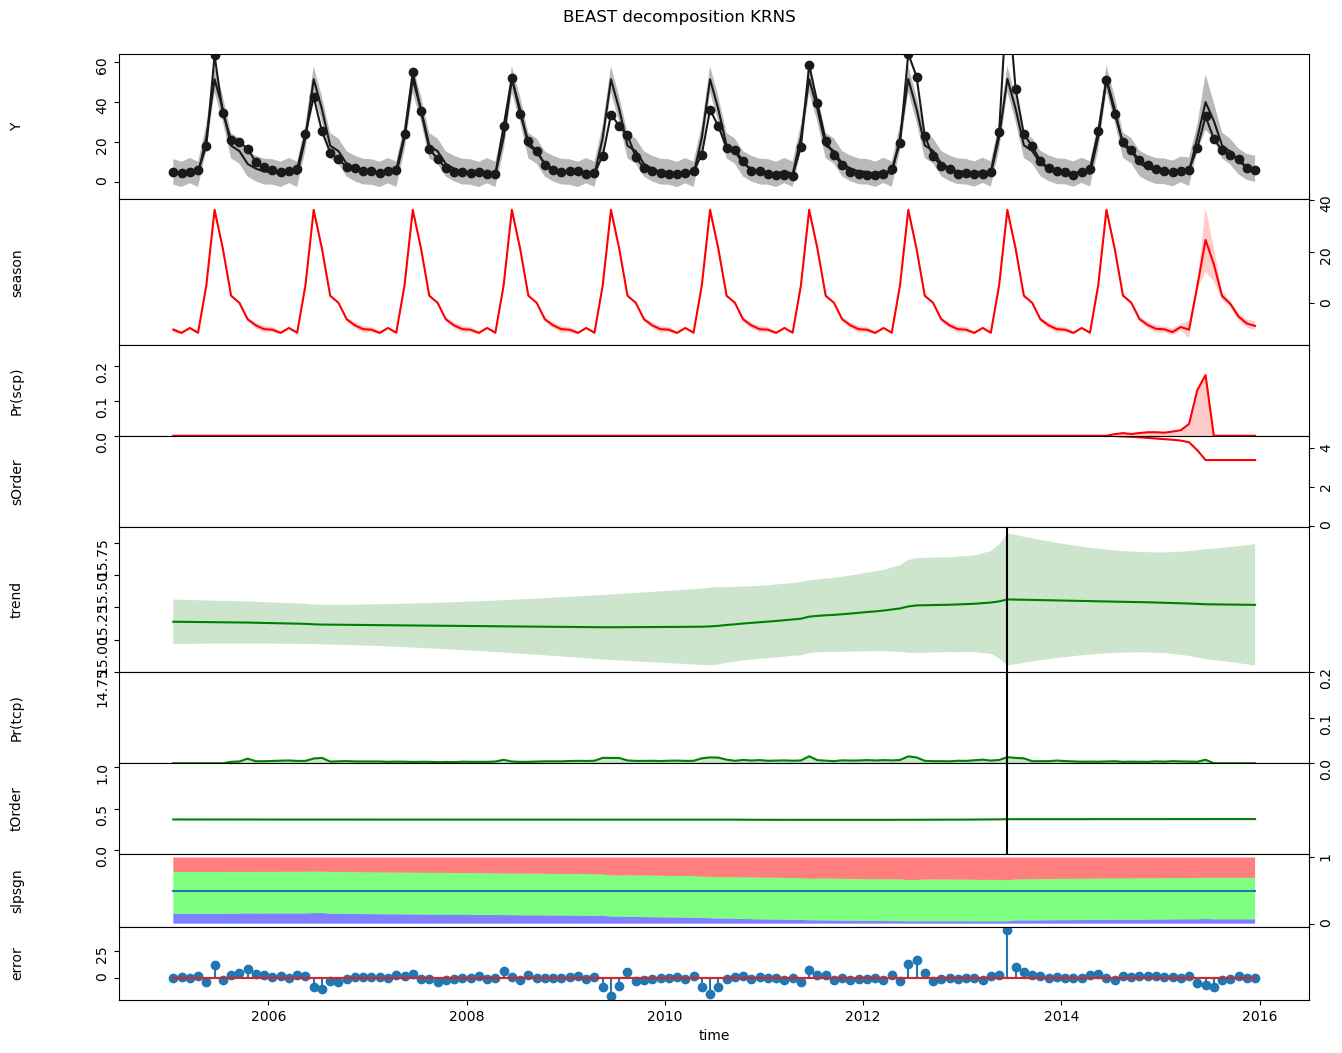

In [104]:
y = krns['Flow'].values
o = rb.beast(
    y,
    start=[2005, 1, 15],
    deltat="1 month",
    period="1 year",
    season="harmonic",
    tcp_minmax=[0,1],
    scp_minmax=[0,10],
)

rb.plot(o, title=f"BEAST decomposition KRNS")
fig = plt.gcf()
fig.set_size_inches(14, 11)

Exception ignored in PyObject_HasAttrString(); consider using PyObject_HasAttrStringWithError(), PyObject_GetOptionalAttrString() or PyObject_GetAttrString():
Traceback (most recent call last):
  File "/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/beast.py", line 498, in beast
    o = cbeast.Rbeast('beast_'+method,Y, metadata, prior, mcmc, extra) 
SystemError: /home/conda/feedstock_root/build_artifacts/python-split_1765018748003/work/Objects/dictobject.c:4167: bad argument to internal function


INFO: Your metadata$startTime=[2005,1,15] is interpreted as 2005/01/15 (Year/Month/Day) and converted to a decimal year of 2005.04. If not making sense, supply a correct start time using one of the following for startTime:  
(1) a numeric scalar (e.g., 2002.33)
(2) a vector of two values (Year, Month) (e.g., c(2002,4) in R, [2002,4] in Matlab/Python) 
(3) a vector of three values (Year, Month, Day) (e.g., c(2002,4,15) in R,  [2002,4,15] in Matlab/Python)
(4) a date string (e.g., "2002-4-15", "2002/04/15", or "2002/4")
(5) a datenum as a list/struct variable (e.g., list(datenum=12523, origin='R') or struct('datenum', 731321, 'origin','matlab')


Model fitted:  Y =  trend + season + error 

INFO: To supress messages, set print_param/print_warning/print_progresss = 0 in beast() and beast_irreg()
INFO: To supress messages, Set extra.printParameter/printWarning/printProgress = 0 in beast123()
INFO: To supress all messaages, set quiet=1 in beast() and beast_irreg() or extra.quiet=1 in beast1

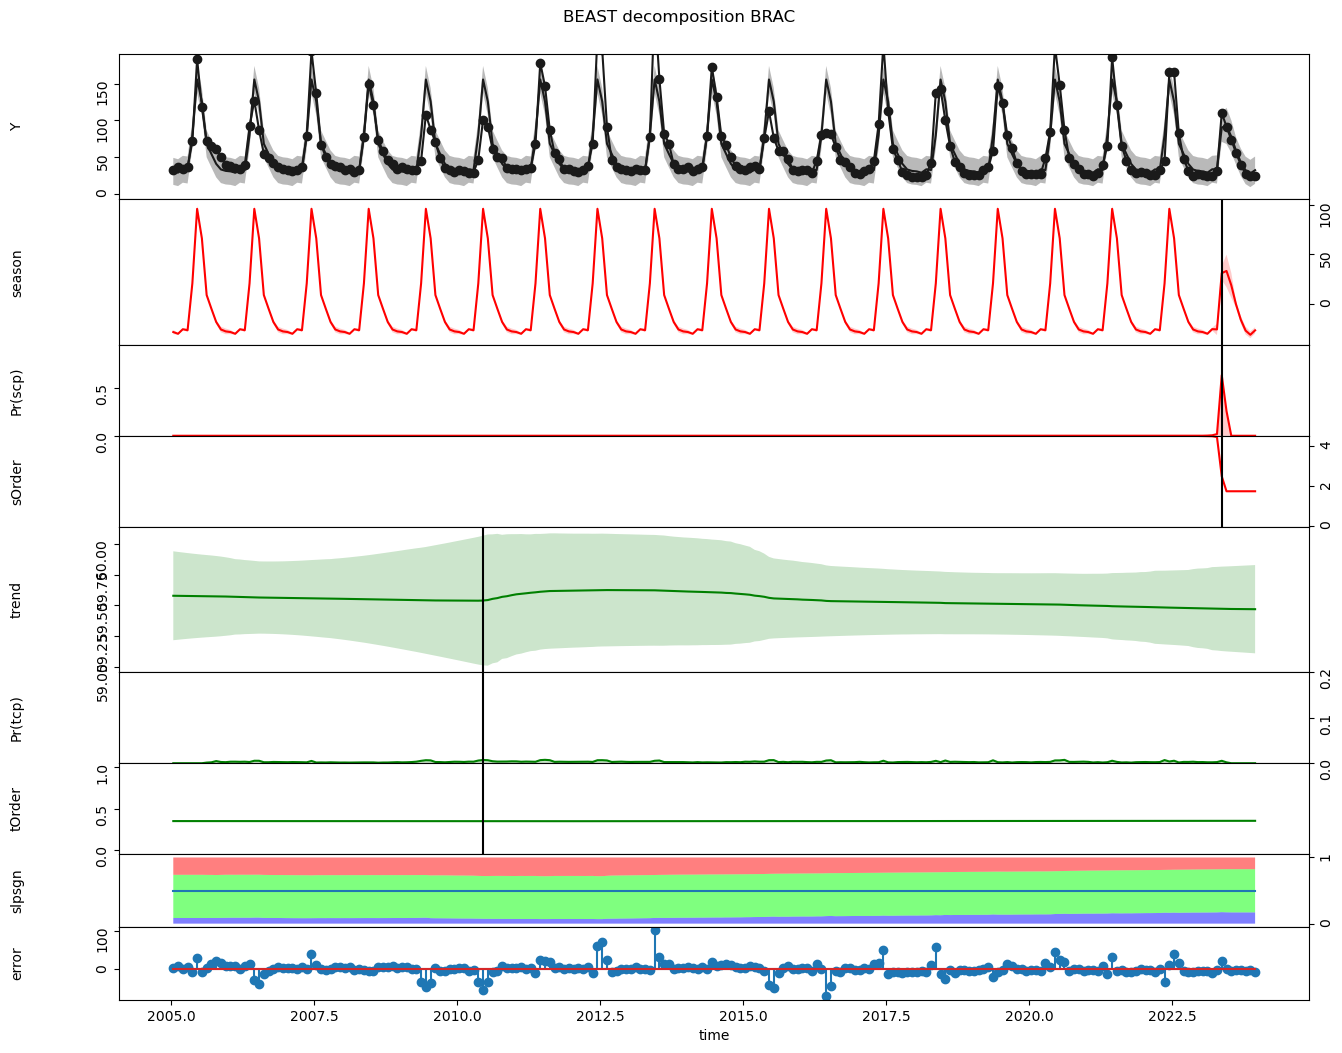

In [103]:
y = brac['Flow'].values
o = rb.beast(
    y,
    start=[2005, 1, 15],
    deltat="1 month",
    period="1 year",
    season="harmonic",
    tcp_minmax=[0,1],
    scp_minmax=[0,10],
)

rb.plot(o, title=f"BEAST decomposition BRAC")
fig = plt.gcf()
fig.set_size_inches(14, 11)

In [75]:
ws = [931, 301, 303, 386, 305, 764, 760, 759, 364]

Exception ignored in PyObject_HasAttrString(); consider using PyObject_HasAttrStringWithError(), PyObject_GetOptionalAttrString() or PyObject_GetAttrString():
Traceback (most recent call last):
  File "/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/beast.py", line 498, in beast
    o = cbeast.Rbeast('beast_'+method,Y, metadata, prior, mcmc, extra) 
SystemError: /home/conda/feedstock_root/build_artifacts/python-split_1765018748003/work/Objects/dictobject.c:4167: bad argument to internal function
/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/plotbeast.py:1015: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
Exception ignored in PyObject_HasAttrString(); consider using PyObject_HasAttrStringWithError(), PyObject_GetOptionalAttrString() or PyObject_GetAttrString():
Traceback (most recent call last):
  File "/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/beast.py", lin

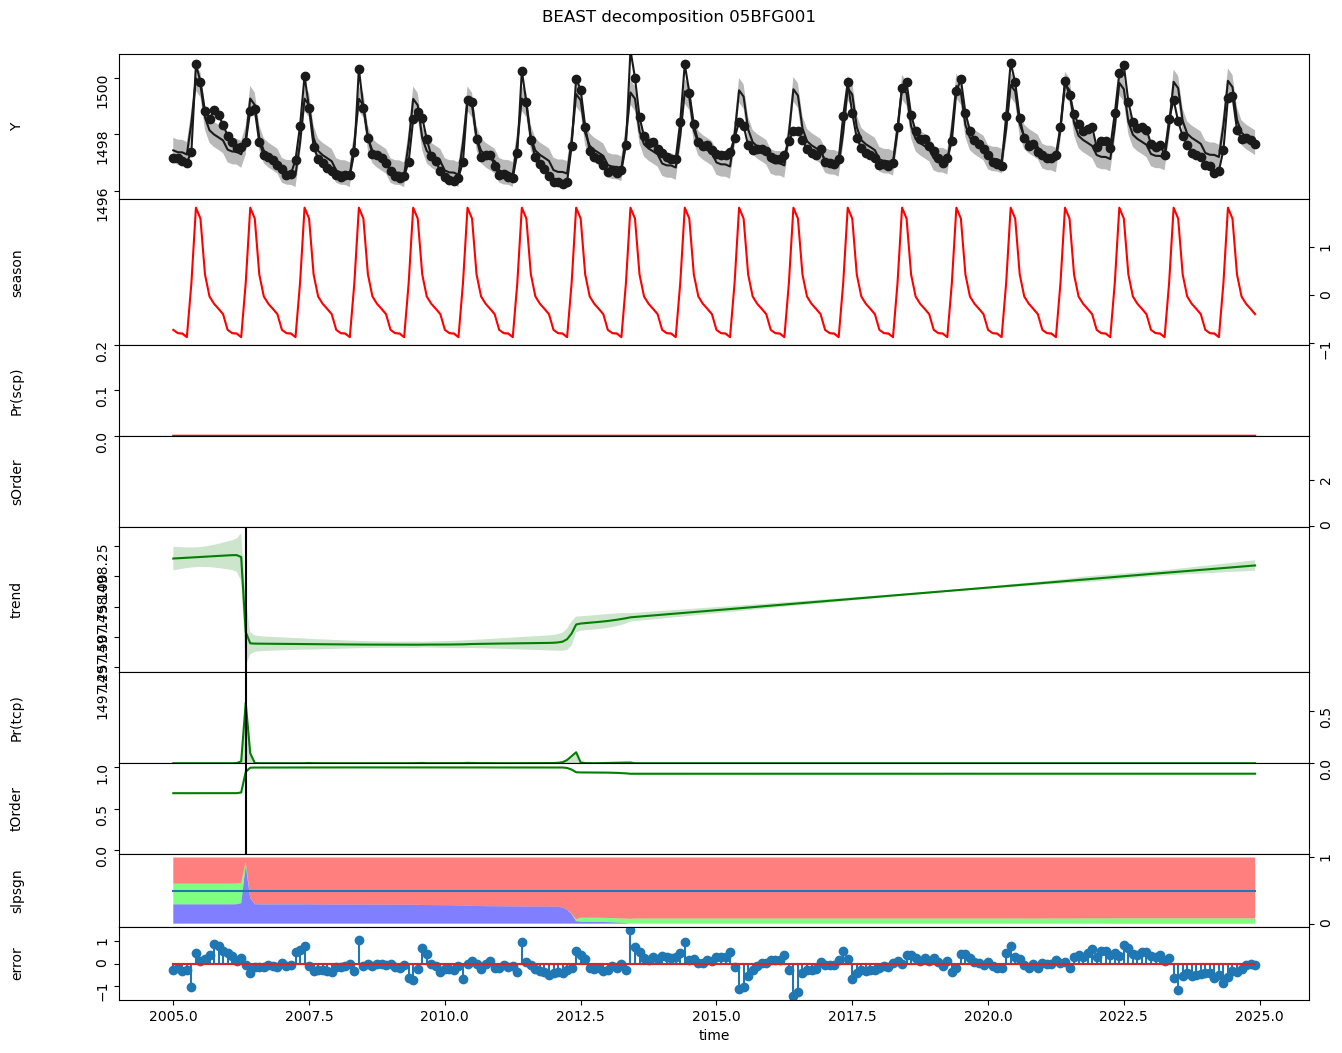

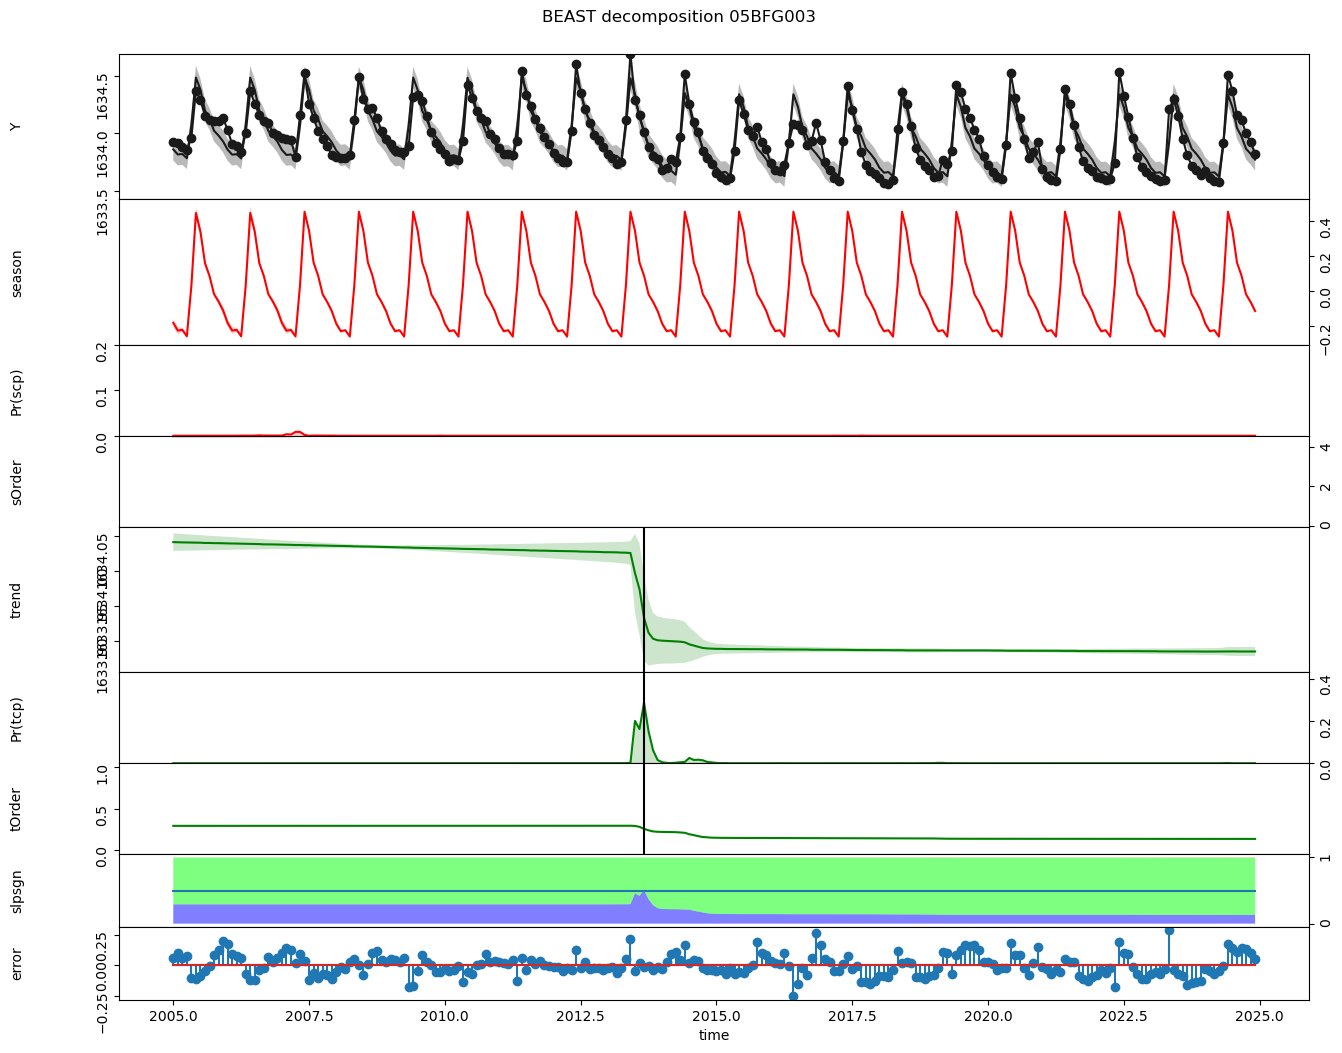

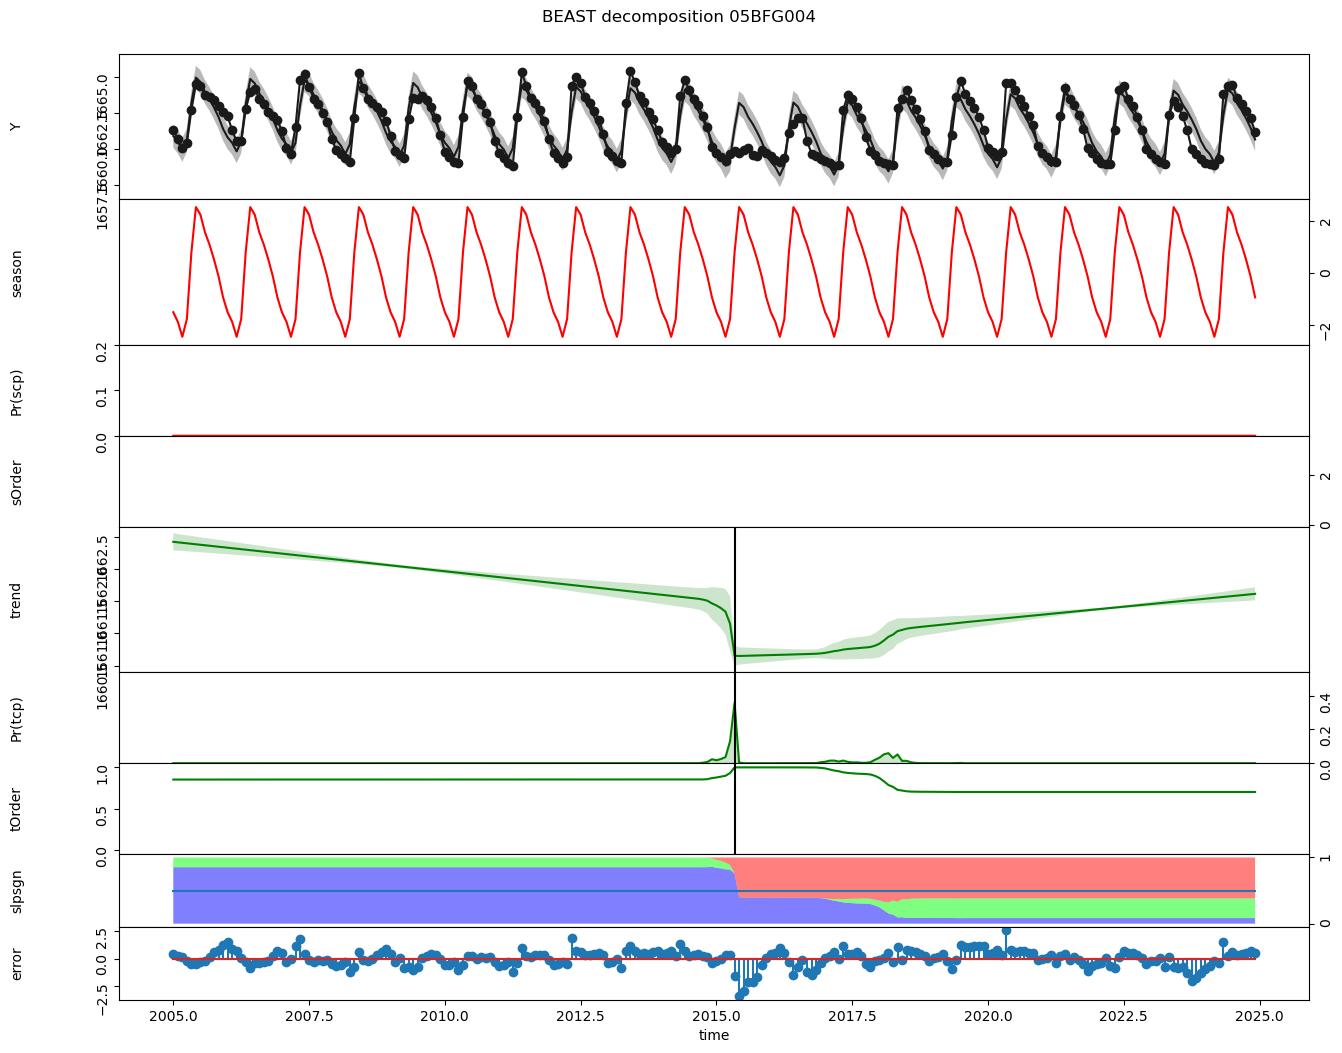

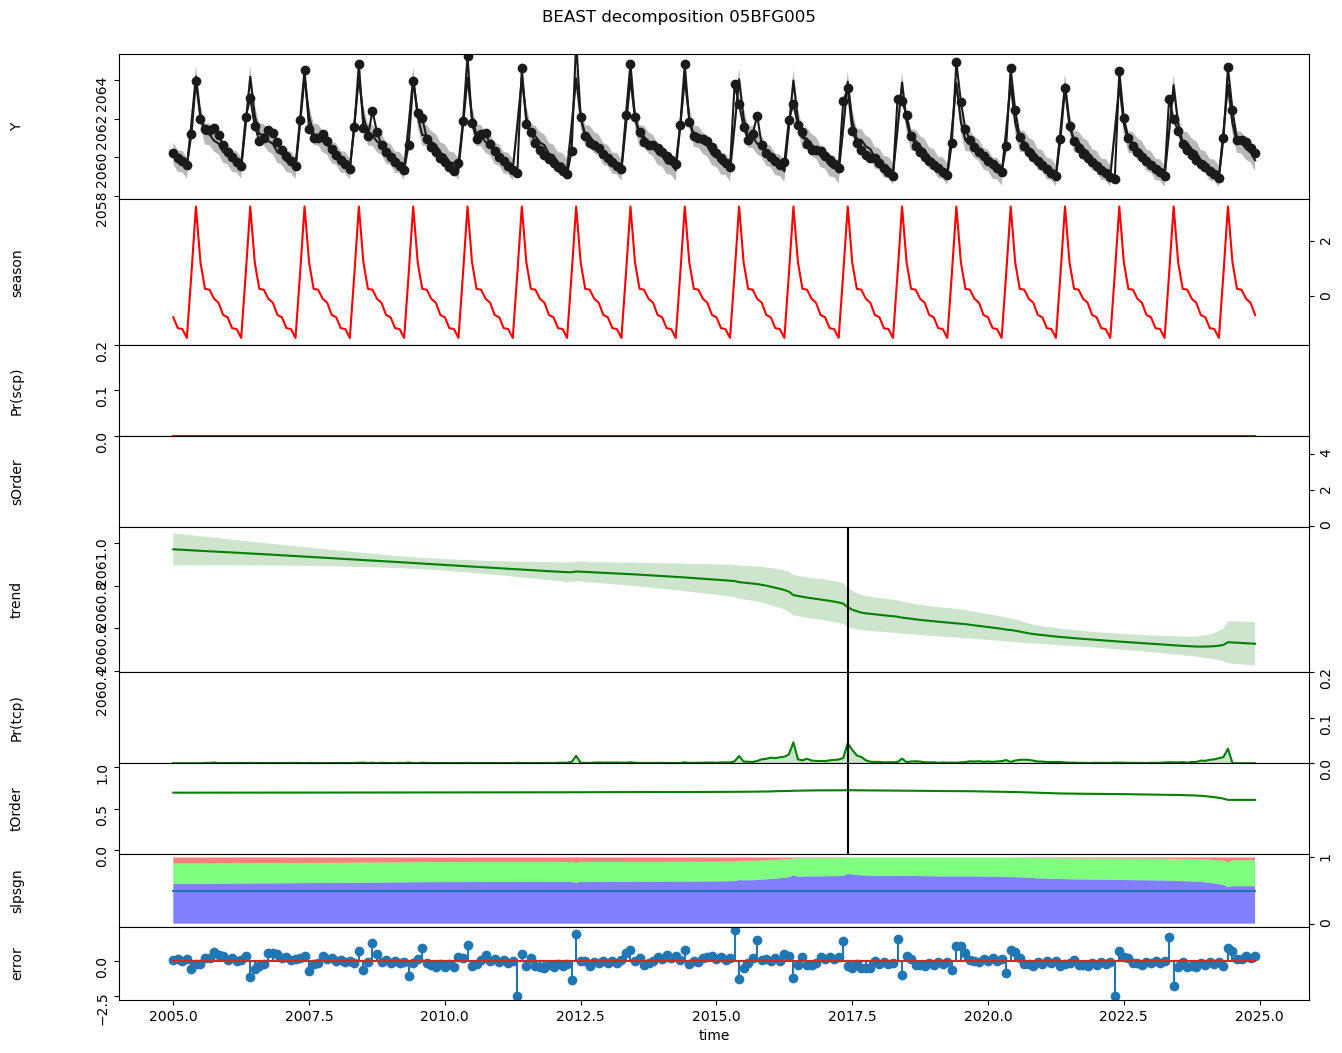

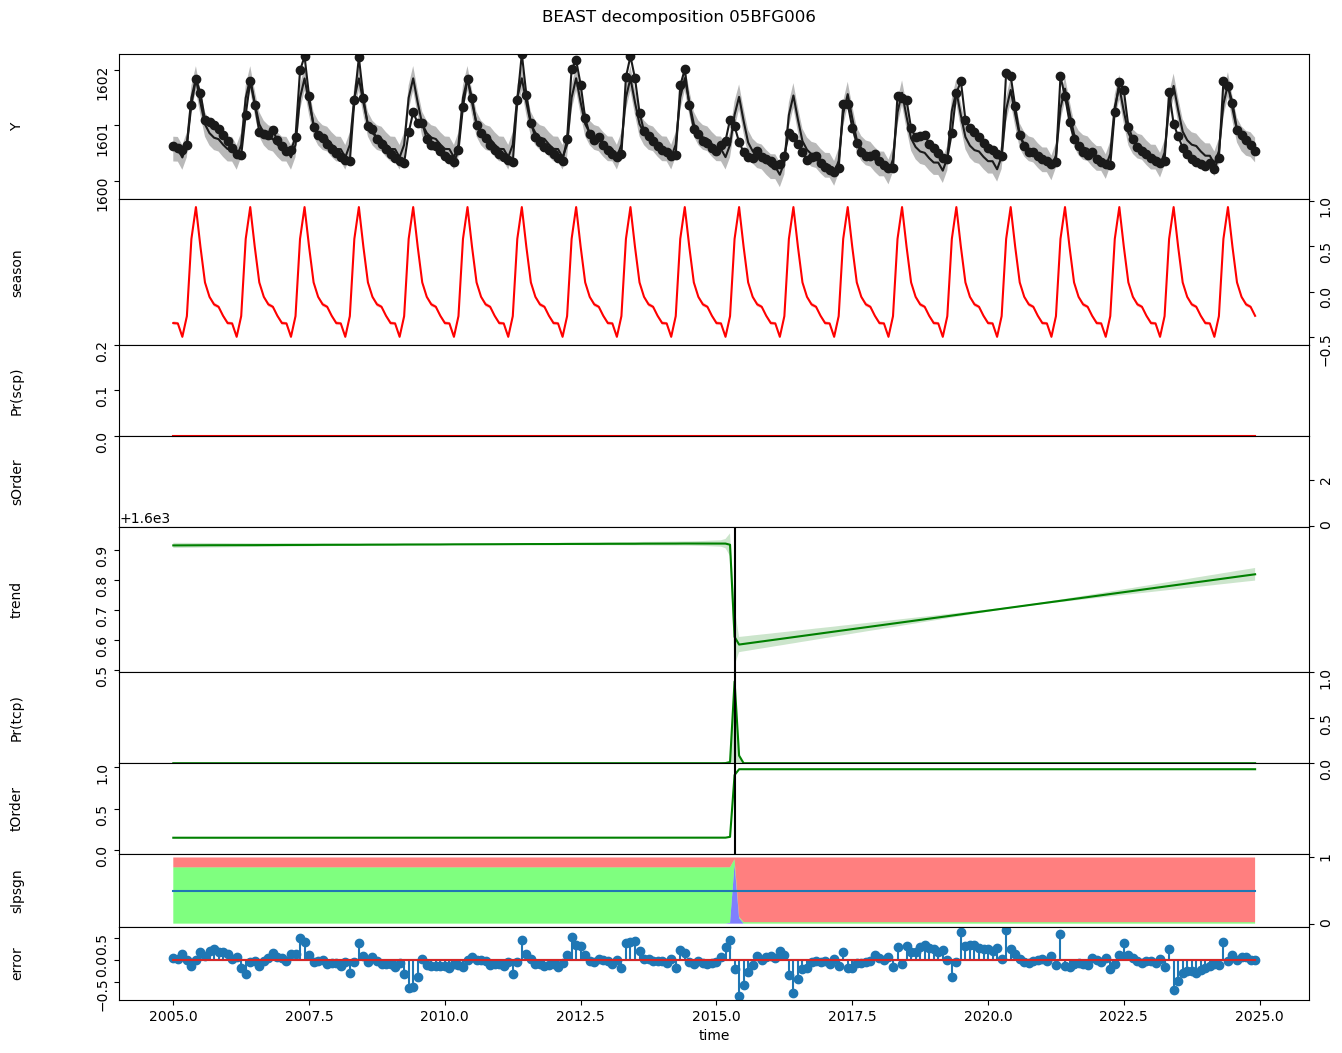

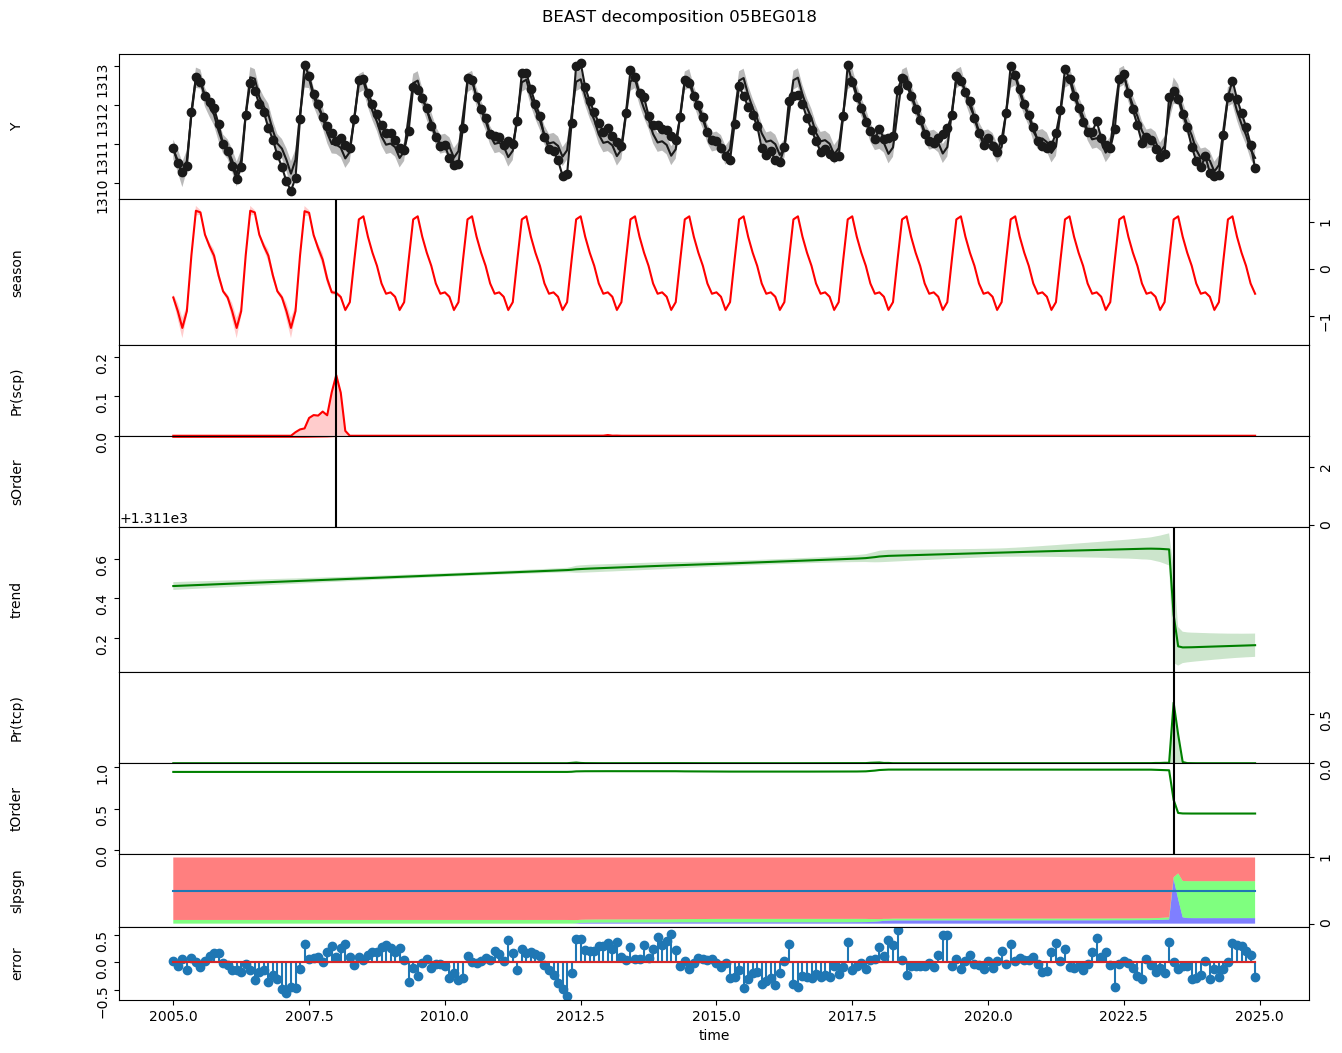

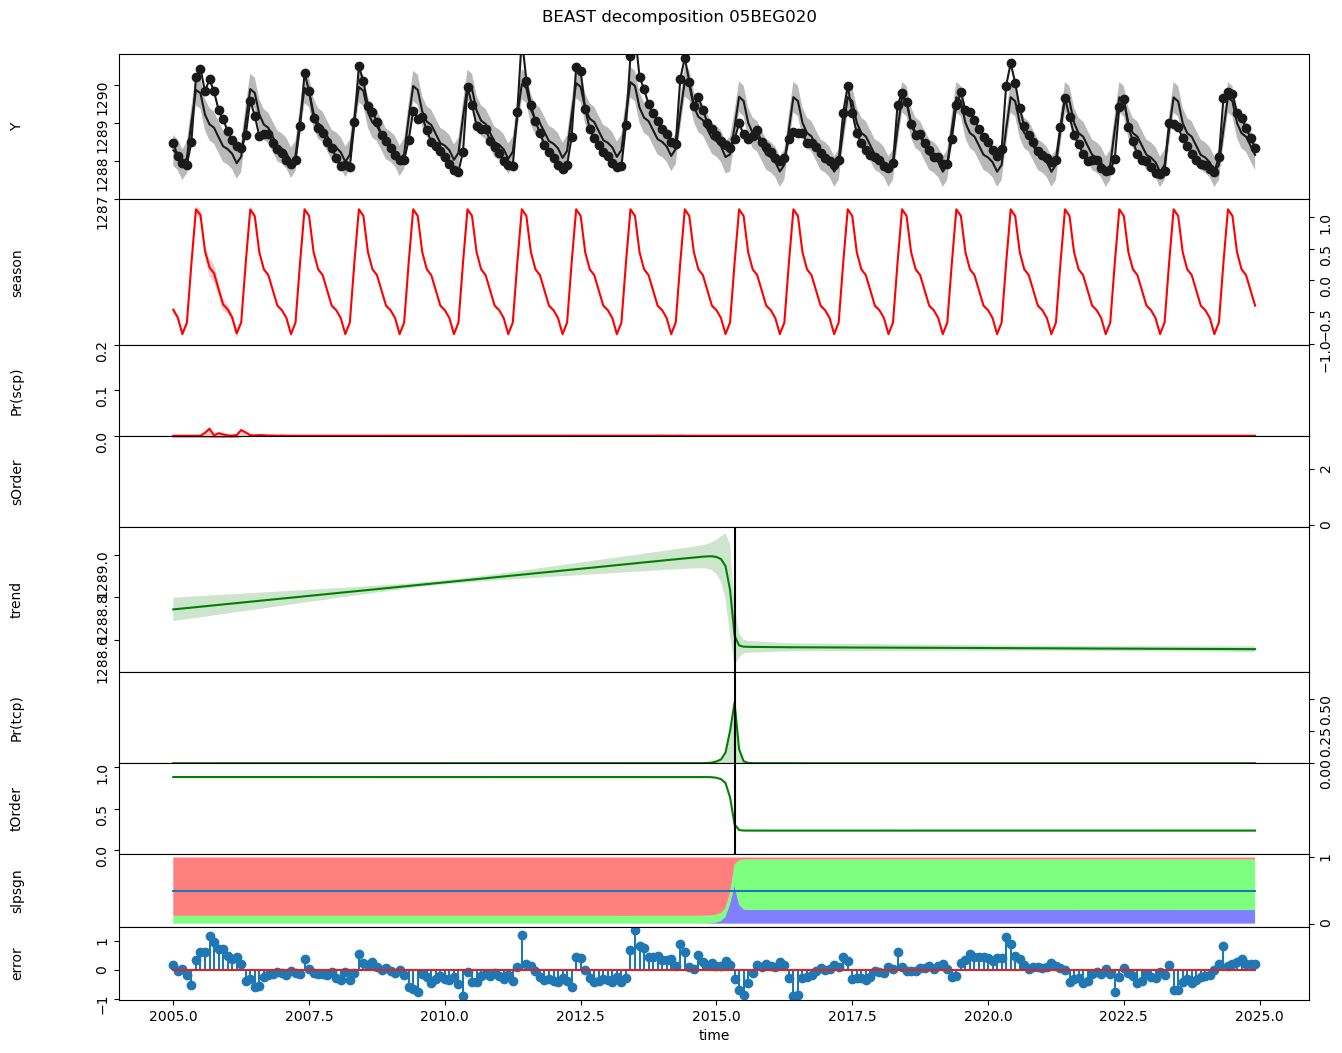

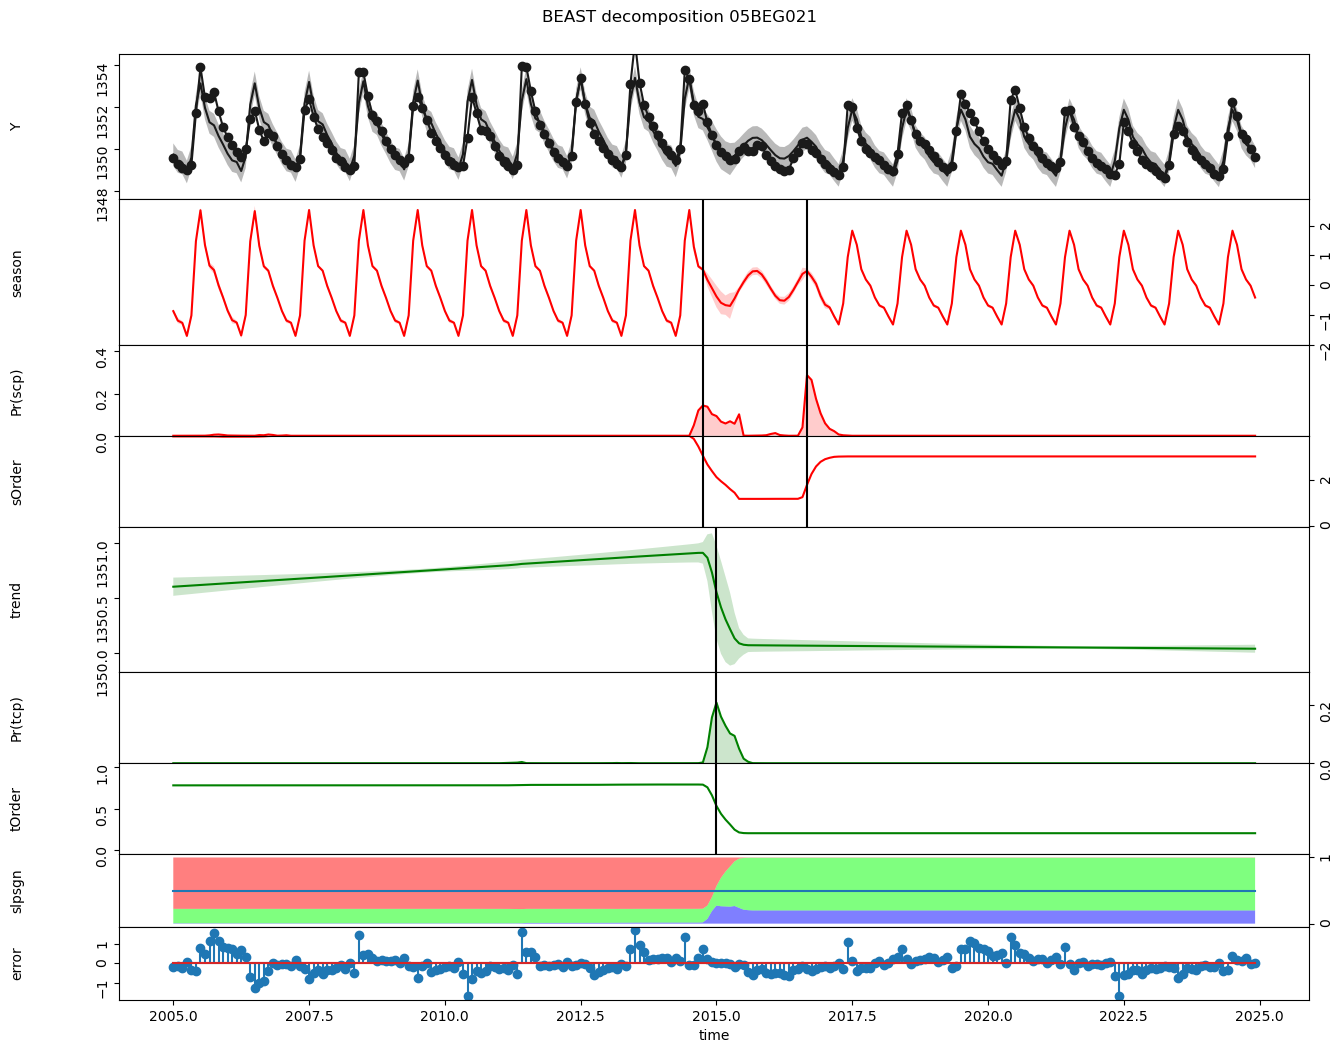

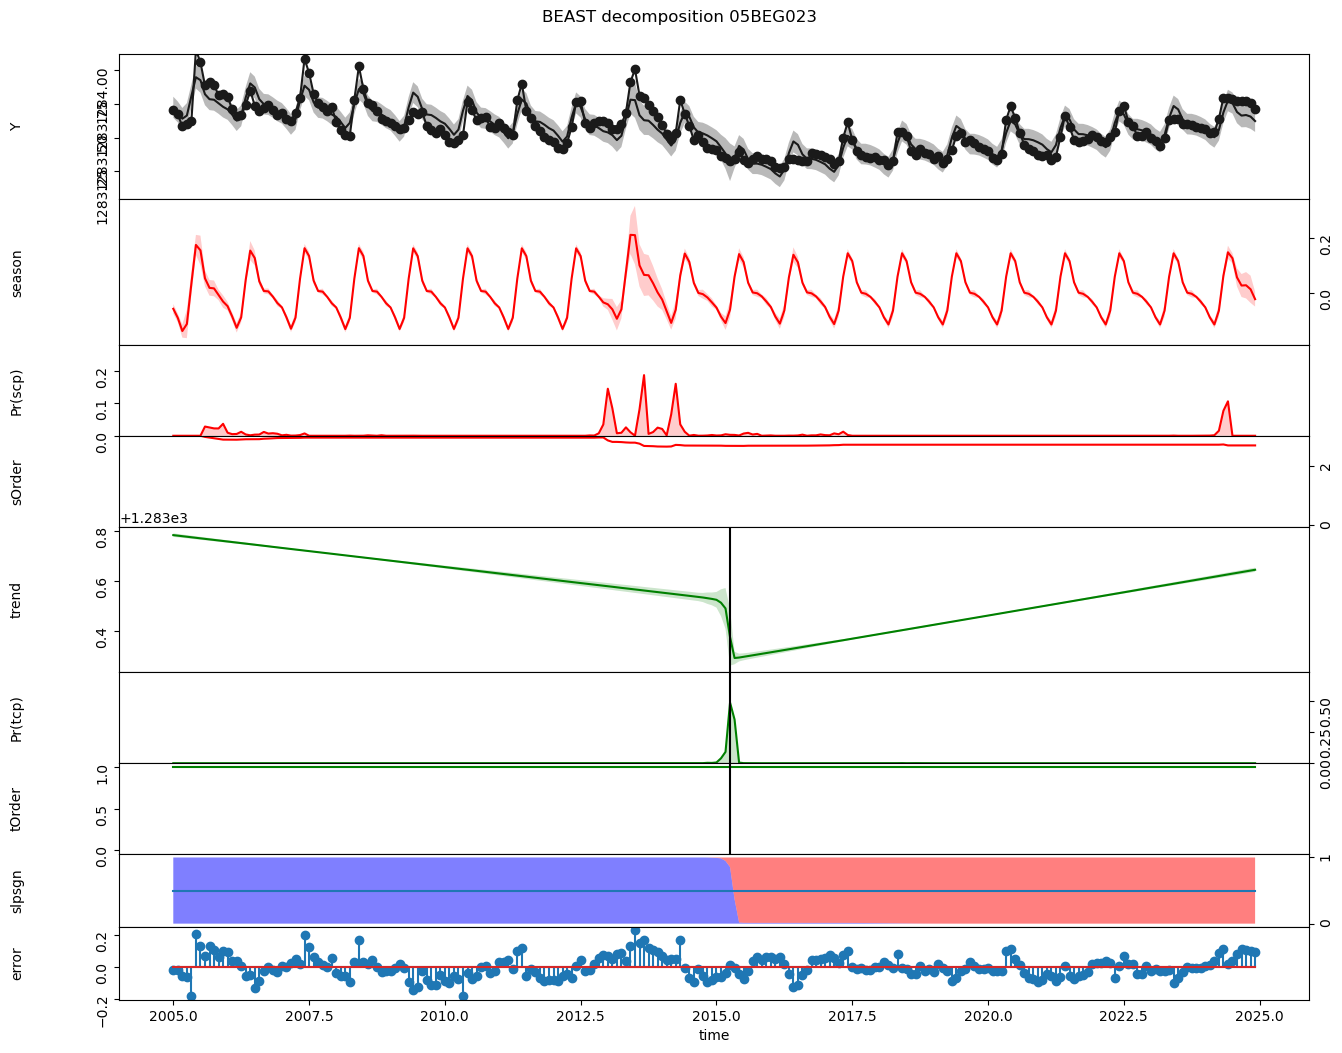

In [ ]:
for w in ws:
    y = df_m[w].values

    o = rb.beast(
        y,
        start=[2005, 1, 1],
        deltat="1 month",
        period="1 year",                  # seasonal cycle length
        season="harmonic",                # harmonic seasonal model
        tcp_minmax=[0,1],
        scp_minmax=[0,10],
        print_progress=False, print_options=False, quiet=True,
    )

    rb.plot(o, title=f"BEAST decomposition GOWN_{w}")
    fig = plt.gcf()
    fig.set_size_inches(14, 11)

In [80]:
harm.index = pd.to_numeric(harm.index)

In [81]:
harm.loc[ws]

,slope_m_yr,slope_se,amp_pp,phase_rad,peak_month,rho,resid_sd,seas_p,snr
931,0.028280,0.013778,1.982650,-3.091619,7.0,0.506714,0.693901,4.947629e-22,2.857251
301,-0.011955,0.006489,0.965901,2.957140,7.0,0.469065,0.342782,6.304709e-22,2.817828
303,-0.052018,0.024593,4.387810,-2.778420,8.0,0.602158,1.082415,6.646951e-37,4.053721
386,-0.011541,0.002526,0.542568,-2.942180,7.0,0.383372,0.148541,1.508083e-34,3.652650
305,-0.026907,0.013356,2.658997,-3.094859,7.0,0.132949,1.027427,8.853494e-27,2.588015
764,-0.050812,0.017576,2.617959,-2.542617,8.0,0.552079,0.828701,2.667479e-25,3.159111
760,-0.000276,0.008394,1.762000,-2.889749,7.0,0.554210,0.395364,8.616124e-42,4.456648
759,-0.017977,0.011985,1.521539,-2.913995,7.0,0.615217,0.513790,5.409710e-23,2.961406
364,-0.010140,0.005275,0.182780,-2.950048,7.0,0.836301,0.141396,3.231174e-09,1.292680


In [83]:
df.columns = df.columns.astype(int)

In [84]:
peaks = df.apply(lambda c: c.groupby(df.index.year).idxmax())
peaks[ws]

,931,301,303,386,305,764,760,759,364
date,,,,,,,,,
2005,2005-06-23,2005-06-21,2005-07-04,2005-06-08,2005-06-08,2005-06-28,2005-06-24,2005-06-20,2005-06-22
2006,2006-06-25,2006-06-18,2006-06-20,2006-06-18,2006-06-15,2006-07-05,2006-06-17,2006-06-18,2006-06-19
2007,2007-06-26,2007-06-18,2007-06-20,2007-06-07,2007-06-19,2007-06-29,2007-06-08,2007-06-20,2007-06-22
2008,2008-06-03,2008-06-11,2008-05-26,2008-06-13,2008-06-04,2008-06-22,2008-07-05,2008-06-14,2008-05-28
2009,2009-06-24,2009-05-30,2009-05-30,2009-06-16,2009-05-30,2009-07-06,2009-06-19,2009-06-19,2009-08-16
2010,2010-06-28,2010-06-17,2010-06-20,2010-06-18,2010-06-17,2010-07-04,2010-06-21,2010-06-19,2010-06-21
2011,2011-06-09,2011-06-01,2011-06-02,2011-06-20,2011-06-17,2011-06-25,2011-06-24,2011-05-29,2011-05-30
2012,2012-06-18,2012-06-09,2012-06-12,2012-06-07,2012-06-06,2012-07-05,2012-06-08,2012-06-12,2012-06-29
2013,2013-06-24,2013-06-21,2013-06-21,2013-06-21,2013-06-20,2013-06-30,2013-06-22,2013-06-23,2013-07-03


In [85]:
def circ_mean_doy(days, period=365.25):
    ang = 2*np.pi * np.asarray(days) / period
    m = np.angle(np.exp(1j*ang).mean())
    return (m % (2*np.pi)) / (2*np.pi) * period

peak_doy = df.apply(
    lambda c: circ_mean_doy(c.groupby(df.index.year).idxmax().dt.dayofyear.values)
)
peak_doy = peak_doy.round(0)

In [86]:
peak_doy[ws]

931    171.0
301    155.0
303    166.0
386    164.0
305    158.0
764    187.0
760    167.0
759    163.0
364    165.0
dtype: float64

In [87]:
peak_doy_harm = ((harm["phase_rad"] % (2*np.pi)) / (2*np.pi) * 365.25).round(0)

In [88]:
peak_doy_harm[ws]

931    186.0
301    172.0
303    204.0
386    194.0
305    185.0
764    217.0
760    197.0
759    196.0
364    194.0
Name: phase_rad, dtype: float64

In [89]:
def doy_to_date(doy, year=2021):
    return pd.Timestamp(f"{year}-01-01") + pd.Timedelta(days=float(doy) - 1)

In [90]:
peak_dates = peak_doy.apply(lambda d: doy_to_date(d))
peak_month = peak_dates.dt.month
peak_label = peak_dates.dt.strftime("%b %d")

In [91]:
peak_label[ws]

931    Jun 20
301    Jun 04
303    Jun 15
386    Jun 13
305    Jun 07
764    Jul 06
760    Jun 16
759    Jun 12
364    Jun 14
dtype: object

In [92]:
peak_dates = peak_doy_harm.apply(lambda d: doy_to_date(d))
peak_month = peak_dates.dt.month
peak_label = peak_dates.dt.strftime("%b %d")
peak_label[ws]

931    Jul 05
301    Jun 21
303    Jul 23
386    Jul 13
305    Jul 04
764    Aug 05
760    Jul 16
759    Jul 15
364    Jul 13
Name: phase_rad, dtype: object